# Machine Learning Analysis of Sleep Health

## 1. Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import sklearn.linear_model as lm
import math
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.base import clone
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from matplotlib.pyplot import boxplot, ylabel
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from scipy.stats import binomtest  # <-- modern version

In [2]:
dat = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
display(dat)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


## 2. Data Preprocessing

The dataset is checked for missing values, the sleep-disorder labels are cleaned, the identifier column is removed, and categorical health variables are prepared for the later analysis.


In [3]:
print(dat.isnull().sum())
dat['Sleep Disorder'] = dat['Sleep Disorder'].fillna("No disorder")
print(dat["Sleep Disorder"].value_counts())
print(dat.isnull().sum())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64
Sleep Disorder
No disorder    219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64


In [4]:
dat.drop(columns=["Person ID"], inplace=True)
print(dat.isnull().sum())

Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64


### 2.1 Blood Pressure Categories

In [5]:
for i in dat["Blood Pressure"].index:    
    systolic = float(dat.loc[i, "Blood Pressure"].split("/")[0]) 
    diastolic = float(dat.loc[i, "Blood Pressure"].split("/")[1])

    if systolic < 90 and diastolic < 60:
        dat.at[i, "Blood Pressure"] = "Low"
    elif 90 <= systolic < 120 and 60 <= diastolic < 80:
        dat.at[i, "Blood Pressure"]="Normal"
    elif 120 <= systolic < 140 or 80 <= diastolic < 90:
        dat.at[i, "Blood Pressure"] = "Prehigh"
    elif 140 <= systolic < 160 or 90 <= diastolic < 100:
        dat.at[i, "Blood Pressure"] ="Stage 1 high"
    elif systolic >= 160 or diastolic >= 100:
        dat.at[i, "Blood Pressure"] = "Stage 2 high"
    else:
        dat.at[i, "Blood Pressure"] = "Uncategorized"
    

In [6]:
dat["Blood Pressure"].value_counts()

Blood Pressure
Prehigh         262
Stage 1 high     71
Normal           41
Name: count, dtype: int64

### 2.2 BMI Category Cleaning

In [7]:
dat["BMI Category"] = dat["BMI Category"].replace("Normal Weight", "Normal")
dat["BMI Category"].value_counts()

BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

## 3. Descriptive Statistics

In [8]:
dat.describe(include='all')

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,374
unique,2,NaN,11,NaN,NaN,NaN,NaN,3,3,NaN,NaN,3
top,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,Prehigh,NaN,NaN,No disorder
freq,189,NaN,73,NaN,NaN,NaN,NaN,216,262,NaN,NaN,219
mean,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,NaN,70.165775,6816.844920,NaN
std,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,NaN,4.135676,1617.915679,NaN
min,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,NaN,65.000000,3000.000000,NaN
25%,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,NaN,68.000000,5600.000000,NaN
50%,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,NaN,70.000000,7000.000000,NaN
75%,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,NaN,72.000000,8000.000000,NaN


In [9]:
dat.describe()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [10]:
categorical_cols = ["Gender", "Occupation", "BMI Category", "Sleep Disorder", "Blood Pressure"]

for col in categorical_cols:
    print(f"\nFrequency table for {col}:")
    print(dat[col].value_counts())


Frequency table for Gender:
Gender
Male      189
Female    185
Name: count, dtype: int64

Frequency table for Occupation:
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

Frequency table for BMI Category:
BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

Frequency table for Sleep Disorder:
Sleep Disorder
No disorder    219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

Frequency table for Blood Pressure:
Blood Pressure
Prehigh         262
Stage 1 high     71
Normal           41
Name: count, dtype: int64


## 4. Exploratory Data Analysis

### 4.1 Feature Distributions

C:\Users\harja\AppData\Local\Temp\ipykernel_20860\2606848081.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,1].set_xticklabels(ax[1,1].get_xticklabels(), rotation=45, ha="right")
C:\Users\harja\AppData\Local\Temp\ipykernel_20860\2606848081.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,1].set_xticklabels([


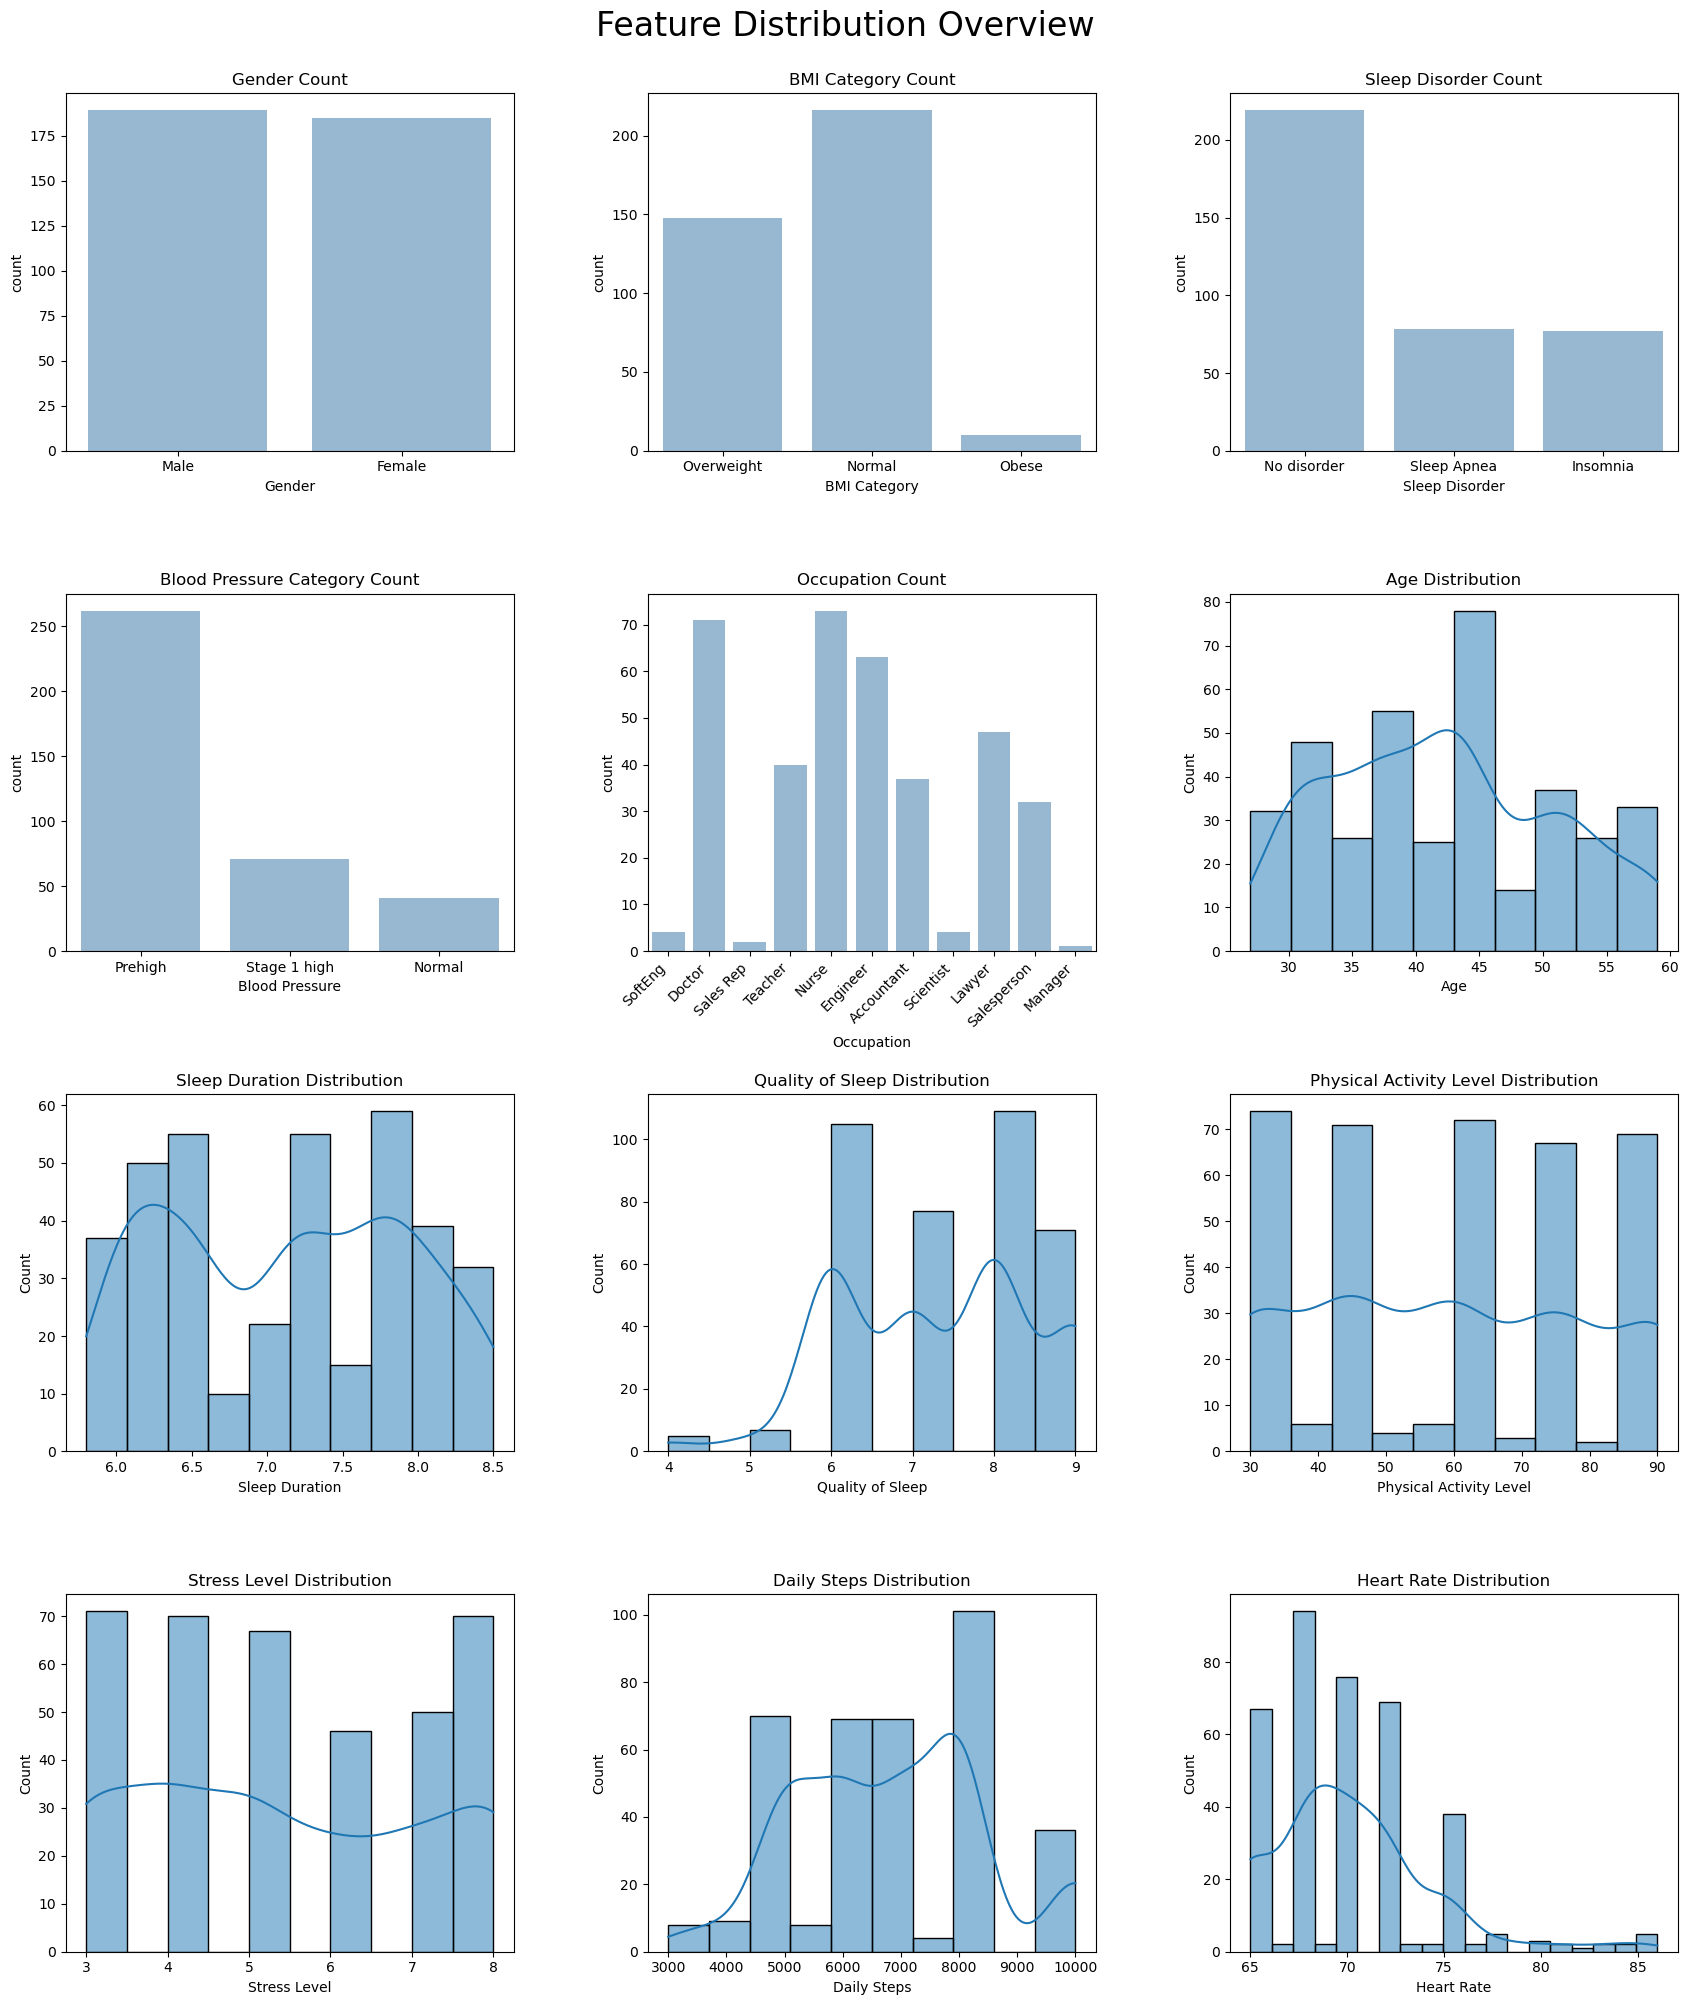

In [11]:
fig,ax = plt.subplots(4,3,figsize=(17, 20))
fig.suptitle("Feature Distribution Overview", fontsize=24, y=1.0)
sns.reset_defaults()


sns.countplot(x = 'Gender', data = dat, ax = ax[0,0], color="#8ebad9")
sns.countplot(x = 'BMI Category', data = dat, ax = ax[0,1], color="#8ebad9")
sns.countplot(x = 'Sleep Disorder', data = dat, ax = ax[0,2], color="#8ebad9")
sns.countplot(x = 'Blood Pressure', data = dat, ax = ax[1,0], color="#8ebad9")
sns.countplot(x = 'Occupation', data = dat, ax = ax[1,1],color="#8ebad9")

sns.histplot(x = 'Age', data = dat, ax = ax[1,2], bins = 10, kde=True )
sns.histplot(x = 'Sleep Duration', data = dat, ax = ax[2,0], bins = 10,kde=True  )
sns.histplot(x = 'Quality of Sleep', data = dat, ax = ax[2,1],kde=True)
sns.histplot(x = 'Physical Activity Level', data = dat, ax = ax[2,2], bins = 10, kde=True)
sns.histplot(x = 'Stress Level', data = dat, ax = ax[3,0], kde=True)
sns.histplot(x = 'Daily Steps', data = dat, ax = ax[3,1], bins = 10, kde=True)
sns.histplot(x = 'Heart Rate', data = dat, ax = ax[3,2], kde=True)


ax[0,0].set_title('Gender Count')
ax[0,1].set_title('BMI Category Count')
ax[0,2].set_title('Sleep Disorder Count')
ax[1,0].set_title('Blood Pressure Category Count')
ax[1,1].set_title('Occupation Count')
ax[1,2].set_title('Age Distribution')
ax[2,0].set_title('Sleep Duration Distribution')
ax[2,1].set_title('Quality of Sleep Distribution')
ax[2,2].set_title('Physical Activity Level Distribution')
ax[3,0].set_title('Stress Level Distribution')
ax[3,1].set_title('Daily Steps Distribution')
ax[3,2].set_title('Heart Rate Distribution')


for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        if not ax[i, j].has_data():
            fig.delaxes(ax[i, j])
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.3)


ax[1,1].set_xticklabels(ax[1,1].get_xticklabels(), rotation=45, ha="right")

ax[1,1].set_xticklabels([
    "SoftEng" if x.get_text() == "Software Engineer" else
    "Sales Rep" if x.get_text() == "Sales Representative" else
    "Med Asst" if x.get_text() == "Medical Assistant" else
    "Lab Tech" if x.get_text() == "Laboratory Technician" else
    "Civil Eng" if x.get_text() == "Civil Engineer" else
    "Mech Eng" if x.get_text() == "Mechanical Engineer" else
    "Comp Op" if x.get_text() == "Computer Operator" else
    x.get_text()
    for x in ax[1,1].get_xticklabels()
])
plt.show()


### 4.2 Outlier Analysis

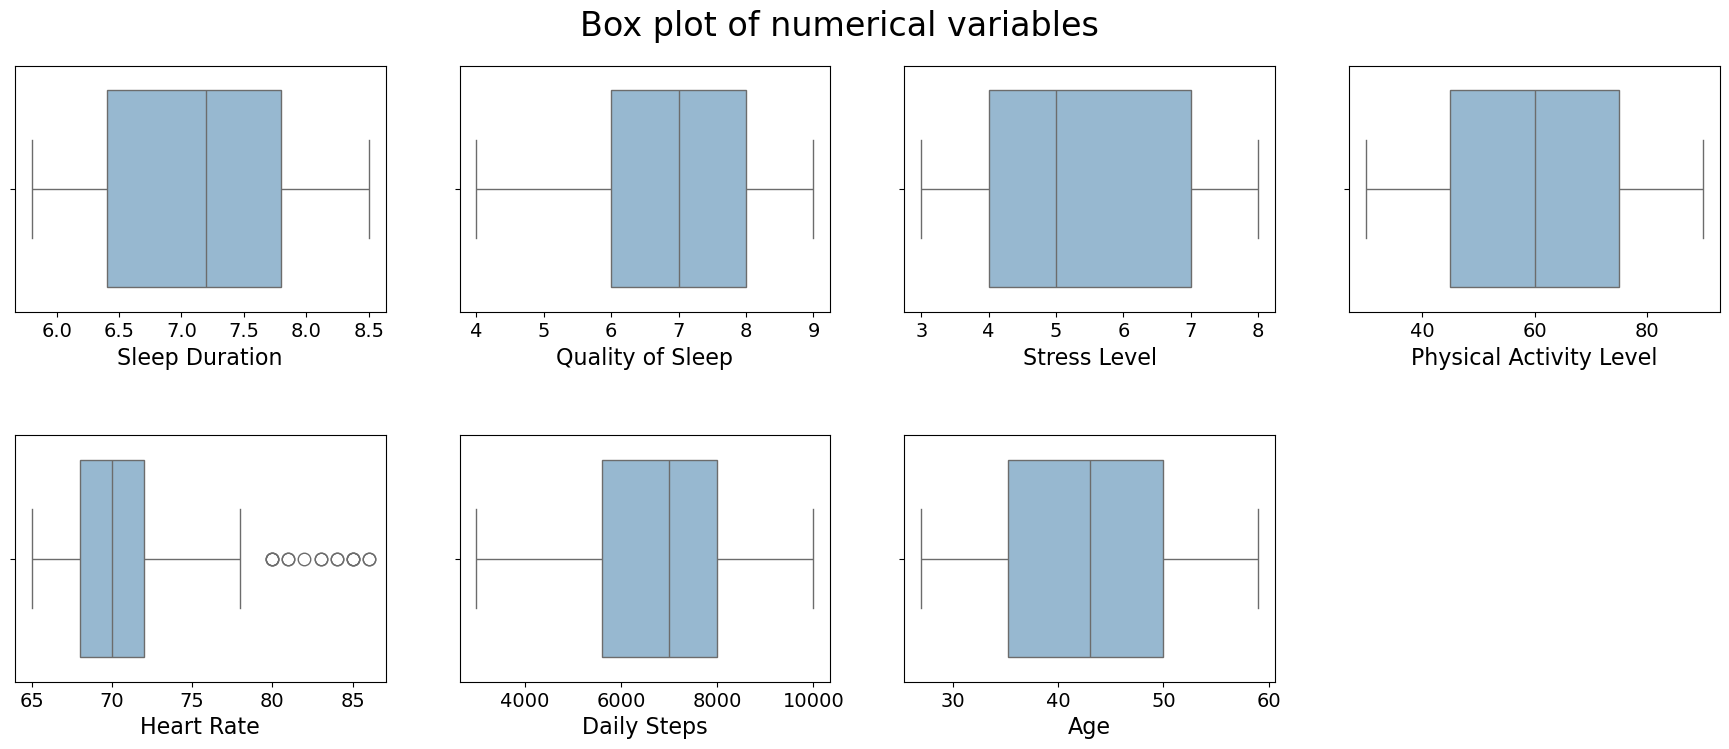

In [12]:
features = [
    'Sleep Duration',
    'Quality of Sleep',
    'Stress Level',
    'Physical Activity Level',
    'Heart Rate',
    'Daily Steps',
    'Age'
]

fig, ax = plt.subplots(2, 4, figsize=(22, 8))
ax = ax.flatten()

sns.set_context("talk", font_scale=1.6) 

plt.subplots_adjust(hspace=0.5)

for i, col in enumerate(features):
    sns.boxplot(data=dat, x=col, color="#8ebad9", ax=ax[i])
    ax[i].set_xlabel(col, fontsize=16)    
    ax[i].tick_params(axis='both', labelsize=14)  

fig.delaxes(ax[-1])

fig.suptitle("Box plot of numerical variables", fontsize=24, y=0.95) 

plt.show()
plt.show()

### 4.3 Relationships Between Numerical Features

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


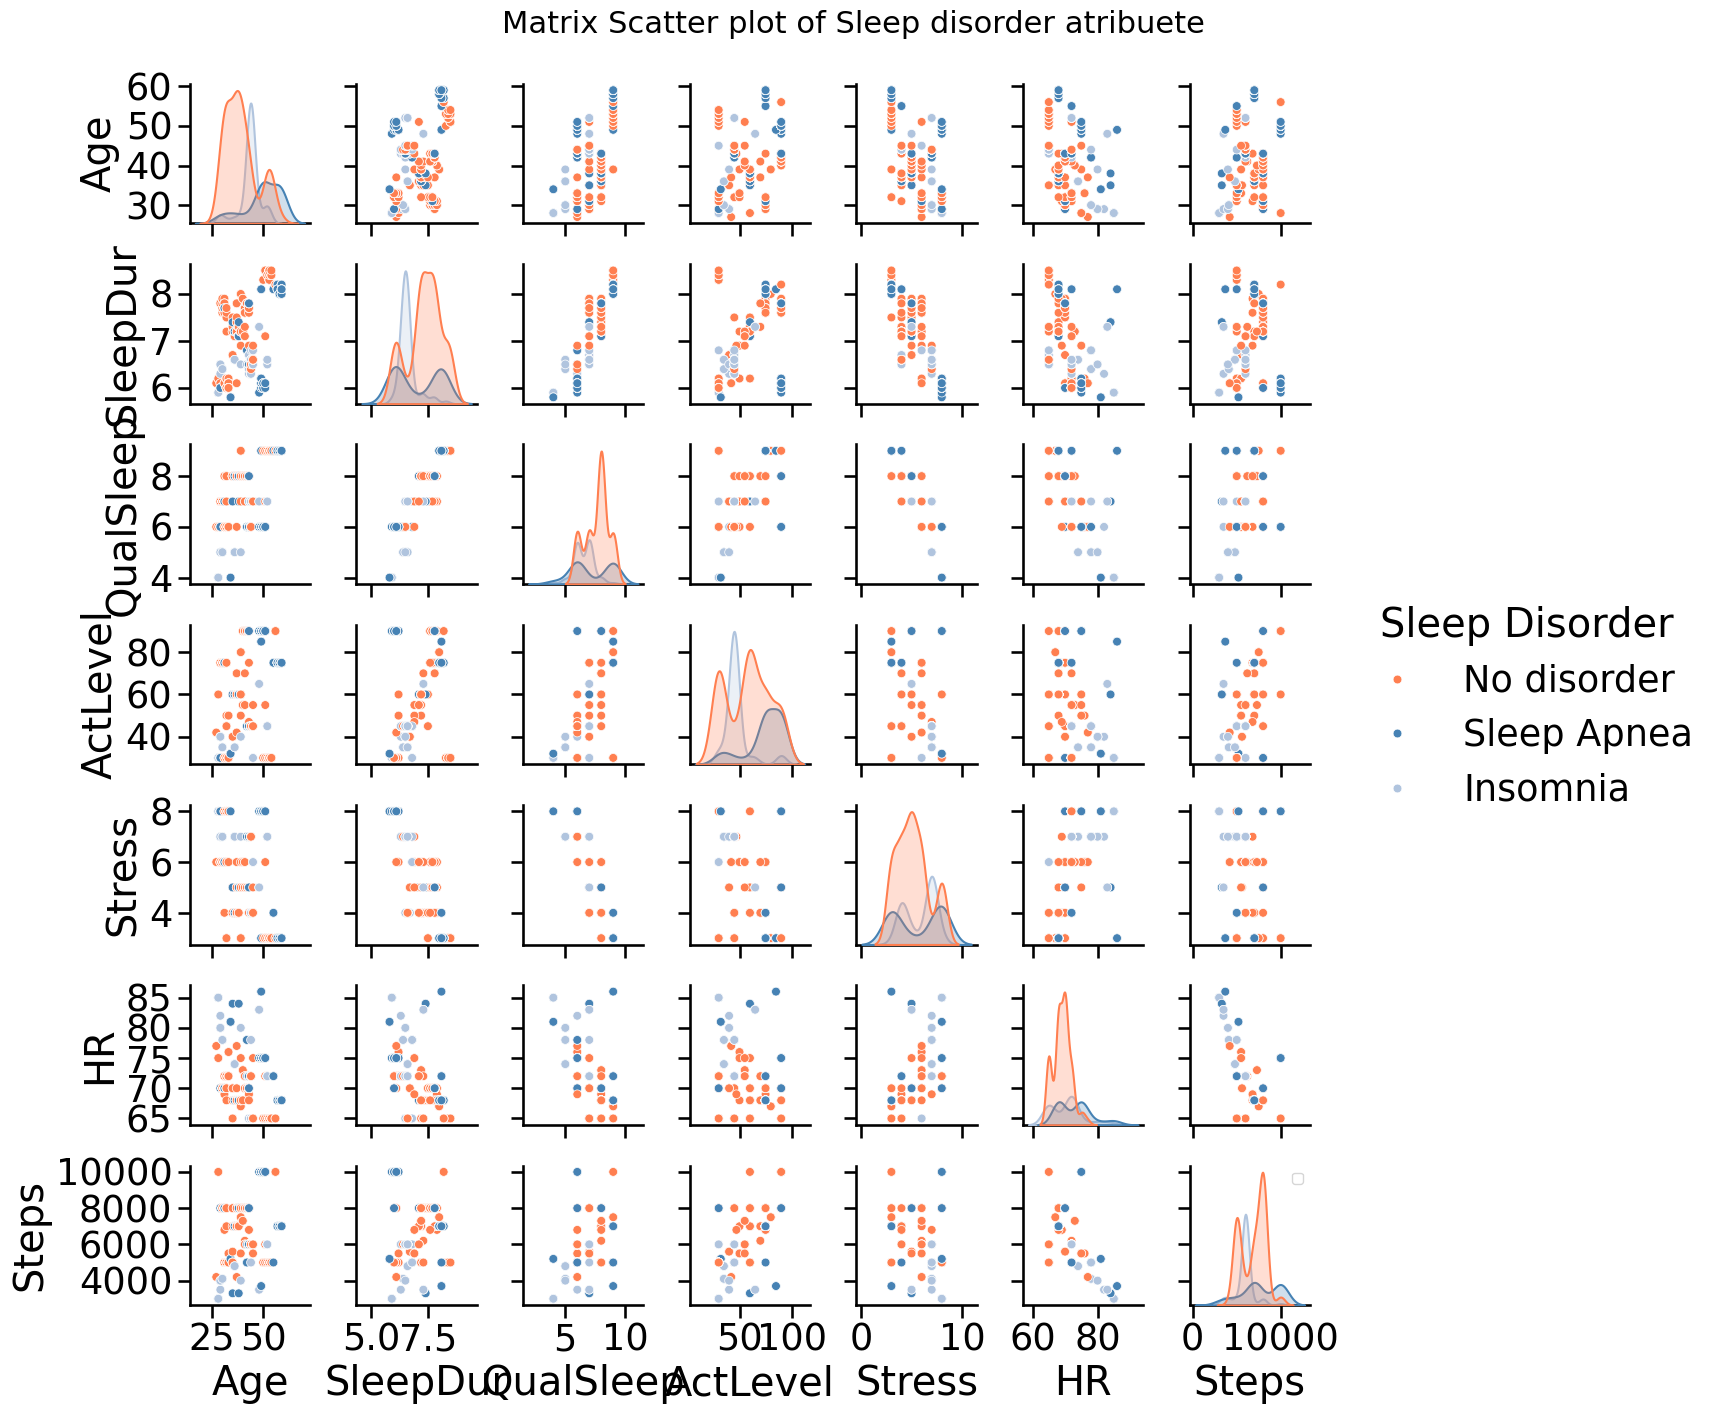

In [13]:
custom_palette = {
    "No disorder": "coral",
    "Sleep Apnea": "steelblue",
    "Insomnia": "lightsteelblue"}

ax=sns.pairplot(data=dat ,hue='Sleep Disorder',palette=custom_palette, height=2,plot_kws={'s': 40})
plt.suptitle("Matrix Scatter plot of Sleep disorder atribuete", fontsize=22, y=1.02)

sns.reset_defaults()


rename_map = {

    "Sleep Duration": "SleepDur",
    "Quality of Sleep": "QualSleep",
    "Physical Activity Level": "ActLevel",
    "Stress Level": "Stress",
    "Heart Rate": "HR",
    "Daily Steps": "Steps"
}
for i, ax_row in enumerate(ax.axes):
    for j, ax_ in enumerate(ax_row):
        # Set x label
        if i == len(ax_row) - 1:
            xlabel = rename_map.get(ax.x_vars[j], ax.x_vars[j])
            ax_.set_xlabel(xlabel)
        # Set y label
        if j == 0:
            ylabel = rename_map.get(ax.y_vars[i], ax.y_vars[i])
            ax_.set_ylabel(ylabel)


plt.legend()
plt.show()

### 4.4 Correlation Analysis

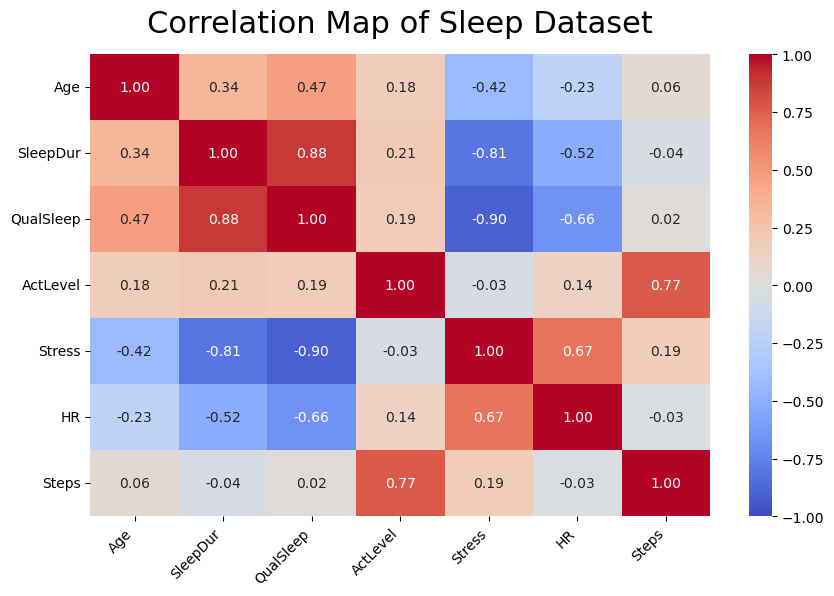

In [14]:
num_cols = dat.select_dtypes(include=['int64', 'float64'])
corr = num_cols.corr()
sns.reset_defaults()

# Plot heatmap
plt.figure(figsize=(10, 6))
ax= sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Map of Sleep Dataset", fontsize=22, y=1.03)

ax.set_xticklabels([
    "Age" if x.get_text() == "Age" else
    "SleepDur" if x.get_text() == "Sleep Duration" else
    "QualSleep" if x.get_text() == "Quality of Sleep" else
    "ActLevel" if x.get_text() == "Physical Activity Level" else
    "Stress" if x.get_text() == "Stress Level" else
    "HR" if x.get_text() == "Heart Rate" else
    "Steps" if x.get_text() == "Daily Steps" else x.get_text()
    for x in ax.get_xticklabels()
], rotation=45, ha="right")

ax.set_yticklabels([
    "Age" if y.get_text() == "Age" else
    "SleepDur" if y.get_text() == "Sleep Duration" else
    "QualSleep" if y.get_text() == "Quality of Sleep" else
    "ActLevel" if y.get_text() == "Physical Activity Level" else
    "Stress" if y.get_text() == "Stress Level" else
    "HR" if y.get_text() == "Heart Rate" else
    "Steps" if y.get_text() == "Daily Steps" else y.get_text()
    for y in ax.get_yticklabels()
], rotation=0)

plt.show()

### 4.5 Sleep Disorder Across Categorical Features

C:\Users\harja\AppData\Local\Temp\ipykernel_20860\604971234.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,1].set_xticklabels(ax[1,1].get_xticklabels(), rotation=45, ha="right")
C:\Users\harja\AppData\Local\Temp\ipykernel_20860\604971234.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,1].set_xticklabels([


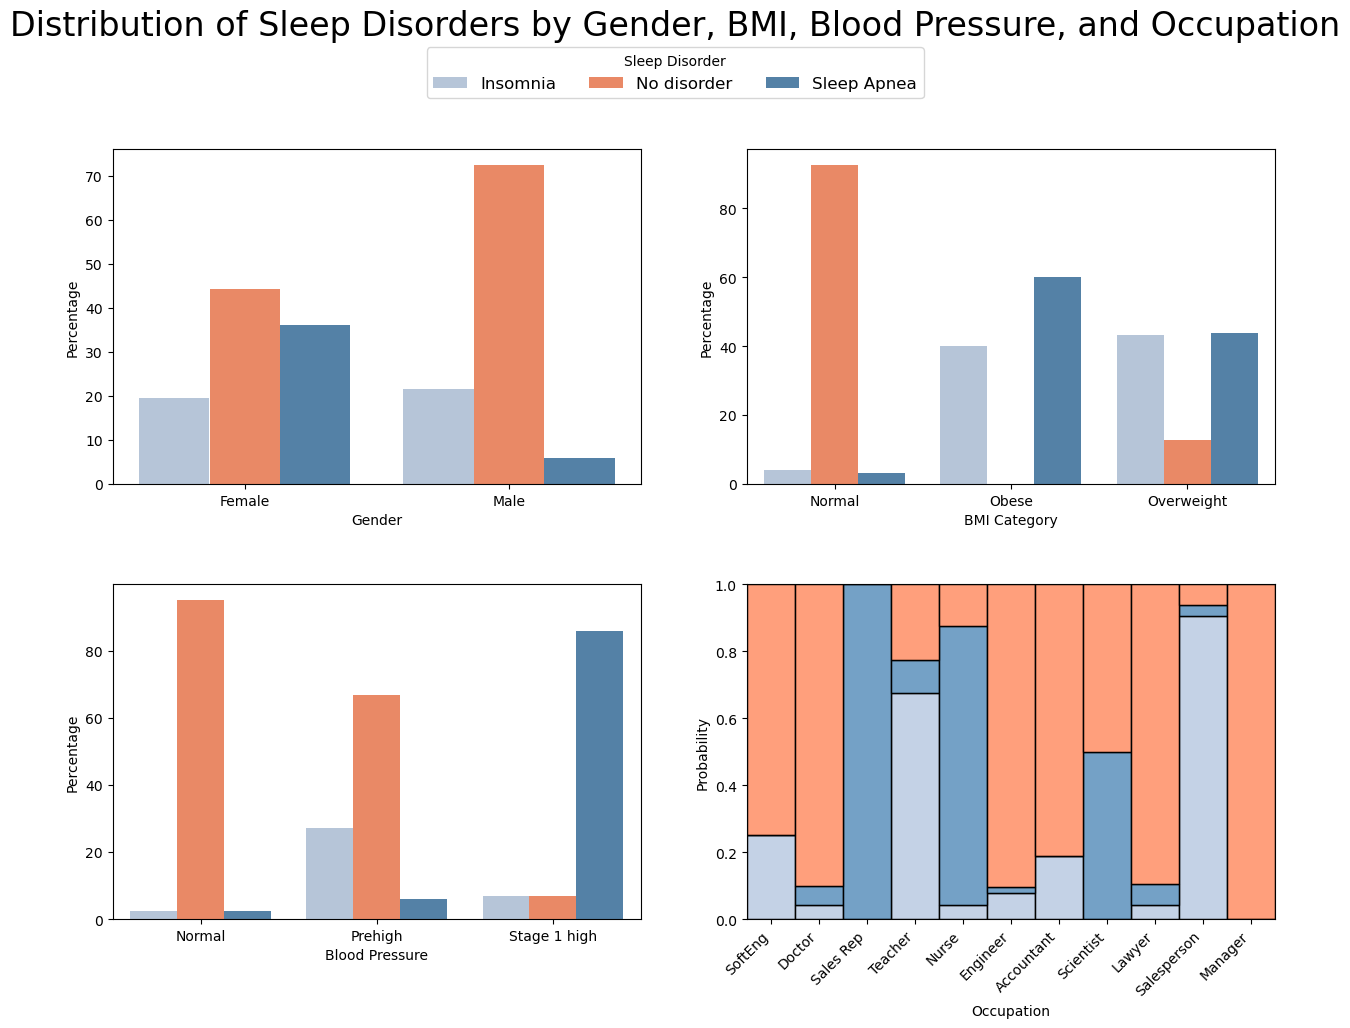

In [15]:
fig, ax= plt.subplots(2,2, figsize=(15,10))
fig.suptitle("Distribution of Sleep Disorders by Gender, BMI, Blood Pressure, and Occupation", fontsize=24, y=1.02)
sns.reset_defaults()


df_counts = dat.groupby(["Gender","Sleep Disorder"]).size().reset_index(name="Count")
df_counts["Percentage"] = df_counts.groupby("Gender")["Count"].transform(lambda x: 100 * x / x.sum())
sns.barplot(ax=ax[0,0], data=df_counts, x="Gender", y="Percentage", hue="Sleep Disorder",palette=custom_palette)
ax[0,0].legend_.remove()


df_counts = dat.groupby(["BMI Category","Sleep Disorder"]).size().reset_index(name="Count")
df_counts["Percentage"] = df_counts.groupby("BMI Category")["Count"].transform(lambda x: 100 * x / x.sum())
sns.barplot(ax= ax[0,1], data=df_counts, x="BMI Category", y="Percentage", hue="Sleep Disorder",palette=custom_palette)
ax[0,1].legend_.remove()


df_counts = dat.groupby(["Blood Pressure","Sleep Disorder"]).size().reset_index(name="Count")
df_counts["Percentage"] = df_counts.groupby("Blood Pressure")["Count"].transform(lambda x: 100 * x / x.sum())

sns.barplot(ax= ax[1,0], data=df_counts, x="Blood Pressure", y="Percentage", hue="Sleep Disorder",palette=custom_palette)
ax[1,0].legend_.remove()

sns.histplot(ax=ax[1,1], data=dat, x="Occupation", hue="Sleep Disorder", multiple="fill",    stat="probability",palette=custom_palette)  
ax[1,1].set_xticklabels(ax[1,1].get_xticklabels(), rotation=45, ha="right")
ax[1,1].legend_.remove()



handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend( handles, labels, loc="upper center",bbox_to_anchor=(0.5, 0.99), ncol=len(labels),title="Sleep Disorder", prop={'size': 12})


plt.subplots_adjust(hspace = 0.3)
ax[1,1].set_xticklabels([
    "SoftEng" if x.get_text() == "Software Engineer" else
    "Sales Rep" if x.get_text() == "Sales Representative" else
    "Med Asst" if x.get_text() == "Medical Assistant" else
    "Lab Tech" if x.get_text() == "Laboratory Technician" else
    "Civil Eng" if x.get_text() == "Civil Engineer" else
    "Mech Eng" if x.get_text() == "Mechanical Engineer" else
    "Comp Op" if x.get_text() == "Computer Operator" else
    x.get_text()
    for x in ax[1,1].get_xticklabels()

])
plt.show()

## 5. Principal Component Analysis (PCA)


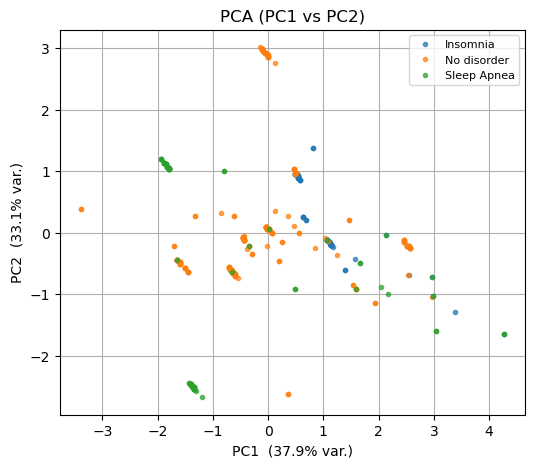

In [16]:
# PCA analysis
num_cols = dat.select_dtypes(include=[np.number]).columns.tolist()
for col in ["Person ID", "Stress Level", "Quality of Sleep"]:
    if col in num_cols:
        num_cols.remove(col)

X = dat[num_cols].copy()


label_candidates = ["Sleep Disorder", "Gender", "Category", "Class", "Label"]
label_col = next((c for c in label_candidates if c in dat.columns), None)

if label_col is not None:
    y = dat.loc[X.index, label_col].astype(str).values
else:
    y = np.array(["All"] * len(X))  

mask_valid = ~X.isna().any(axis=1)
X = X.loc[mask_valid]
y = y[mask_valid]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=4, random_state=0)
B = pca.fit_transform(X_scaled)  
expl_var = pca.explained_variance_ratio_

PC_idx = [0, 1] 
unique_classes = np.unique(y)

fig = plt.figure(figsize=(6, 5))
plt.title("PCA (PC1 vs PC2)")

for cls in unique_classes:
    m = (y == cls)
    plt.plot(B[m, PC_idx[0]], B[m, PC_idx[1]], ".", alpha=0.7, label=str(cls))

plt.xlabel(f"PC{PC_idx[0]+1}  ({expl_var[PC_idx[0]]*100:.1f}% var.)")
plt.ylabel(f"PC{PC_idx[1]+1}  ({expl_var[PC_idx[1]]*100:.1f}% var.)")
if len(unique_classes) > 1:
    plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.show()

### 5.1 Principal Component Coefficients and Explained Variance

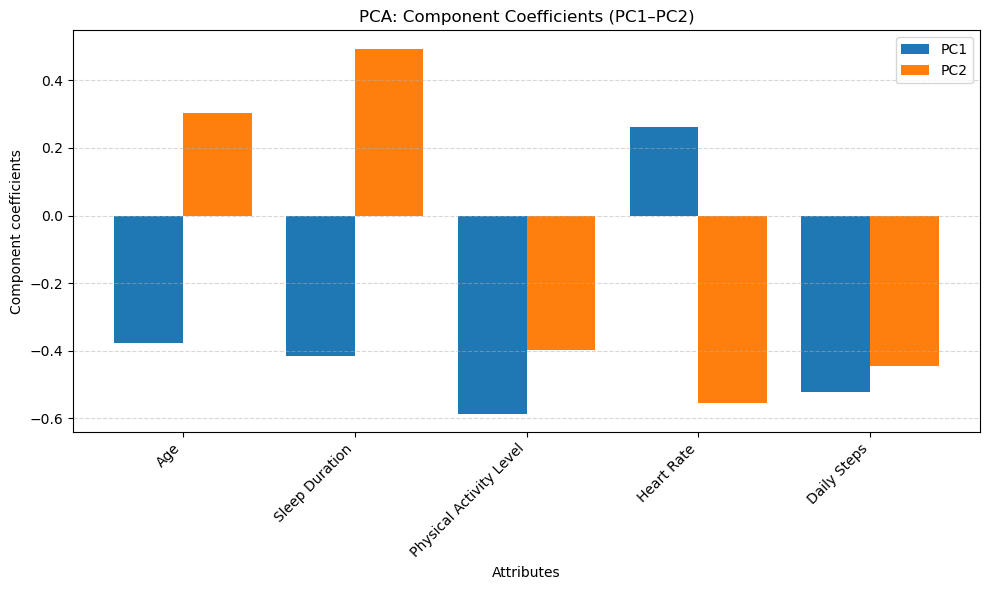

Forklaret varians pr. PC: [0.379 0.331]
Akkumuleret: [0.379 0.71 ]


In [17]:
# PCA analysis
num_cols = dat.select_dtypes(include=[np.number]).columns.tolist()
for col in ["Person ID", "Stress Level", "Quality of Sleep"]:
    if col in num_cols:
        num_cols.remove(col)

X = dat[num_cols].copy().dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_pcs = 2 
pca = PCA(n_components=n_pcs, random_state=0)
pca.fit(X_scaled)

V = pca.components_.T  

bw = 0.8 / n_pcs                      
r = np.arange(1, X.shape[1] + 1)         
plt.figure(figsize=(10, 6))
plt.title("PCA: Component Coefficients (PC1–PC{})".format(n_pcs))

for i in range(n_pcs):
    plt.bar(r + i*bw - 0.4 + bw/2, V[:, i], width=bw, label=f"PC{i+1}")

plt.xticks(r, X.columns, rotation=45, ha="right")
plt.xlabel("Attributes")
plt.ylabel("Component coefficients")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print("Forklaret varians pr. PC:", np.round(pca.explained_variance_ratio_, 3))
print("Akkumuleret:", np.round(pca.explained_variance_ratio_.cumsum(), 3))


### 5.2 PCA Scores and Loadings

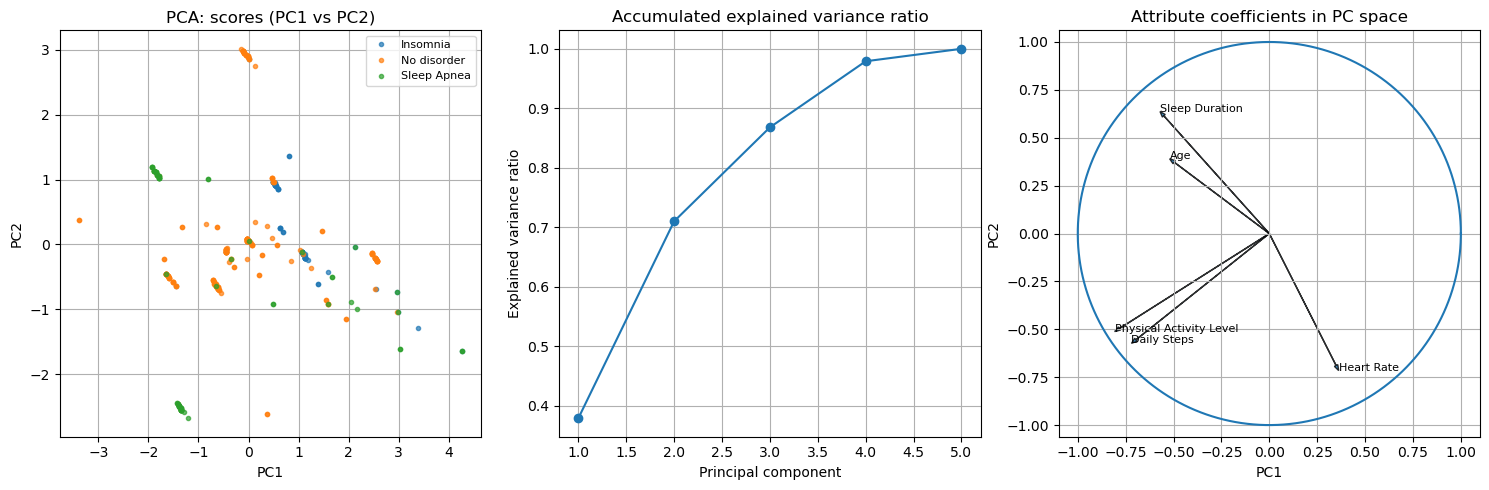

In [19]:
num_cols = dat.select_dtypes(include=[np.number]).columns.tolist()
for col in ["Person ID", "Stress Level", "Quality of Sleep"]:
    if col in num_cols:
        num_cols.remove(col)

X = dat[num_cols].copy().dropna()

label_candidates = ["Sleep Disorder", "Gender", "Category", "Class", "Label"]
label_col = next((c for c in label_candidates if c in dat.columns), None)
y = dat.loc[X.index, label_col].astype(str).values if label_col else np.array(["All"]*len(X))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()               
B = pca.fit_transform(X_scaled)  
V = pca.components_.T            


corr_loadings = V[:, :2] * np.sqrt(pca.explained_variance_[:2])

PC_idxs = [0, 1]  # PC1 vs PC2

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].set_title("PCA: scores (PC1 vs PC2)")
unique_classes = np.unique(y)
for cls in unique_classes:
    m = (y == cls)
    axs[0].plot(B[m, PC_idxs[0]], B[m, PC_idxs[1]], ".", alpha=0.7, label=str(cls))
axs[0].set_xlabel(f"PC{PC_idxs[0]+1}")
axs[0].set_ylabel(f"PC{PC_idxs[1]+1}")
axs[0].grid(True)
if len(unique_classes) > 1:
    axs[0].legend(loc="best", fontsize=8)

axs[1].set_title("Accumulated explained variance ratio")
axs[1].plot(np.arange(1, pca.n_components_ + 1),
            np.cumsum(pca.explained_variance_ratio_), marker="o")
axs[1].set_xlabel("Principal component")
axs[1].set_ylabel("Explained variance ratio")
axs[1].grid(True)

axs[2].set_title("Attribute coefficients in PC space")
for j, attr in enumerate(X.columns):
    axs[2].arrow(0, 0, corr_loadings[j, 0], corr_loadings[j, 1],
                 head_width=0.02, head_length=0.03, length_includes_head=True, alpha=0.8)
    axs[2].text(corr_loadings[j, 0], corr_loadings[j, 1], attr, fontsize=8)

theta = np.linspace(0, 2*np.pi, 400)
axs[2].plot(np.cos(theta), np.sin(theta))
axs[2].set_xlim([-1.05, 1.05]); axs[2].set_ylim([-1.05, 1.05])
axs[2].set_xlabel(f"PC{PC_idxs[0]+1}")
axs[2].set_ylabel(f"PC{PC_idxs[1]+1}")
axs[2].grid(True); axs[2].axis("equal")

plt.tight_layout()
plt.show()


### 5.3 Pairwise Principal-Component Relationships

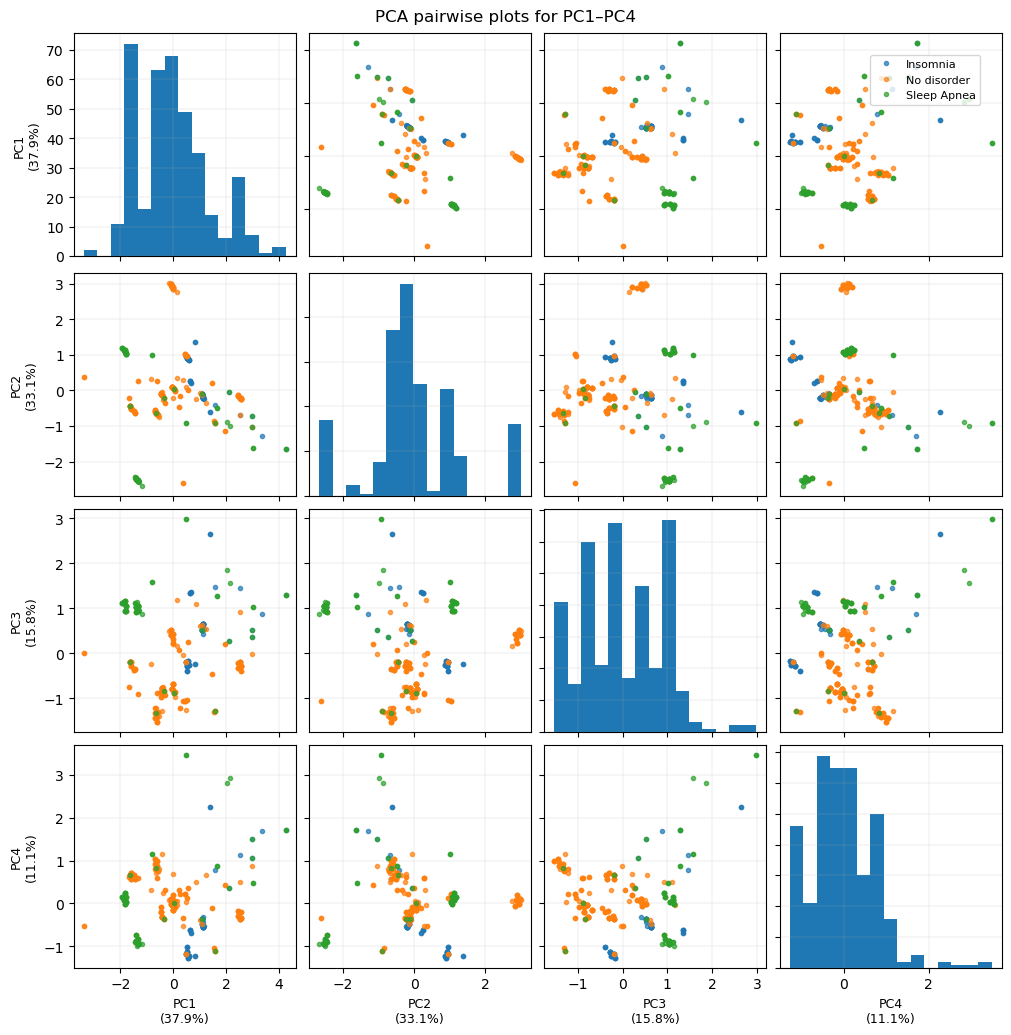

In [ ]:
num_cols = dat.select_dtypes(include=[np.number]).columns.tolist()
for col in ["Person ID", "Stress Level", "Quality of Sleep"]:
    if col in num_cols:
        num_cols.remove(col)

X = dat[num_cols].copy().dropna()

label_candidates = ["Sleep Disorder", "Gender", "Category", "Class", "Label"]
label_col = next((c for c in label_candidates if c in dat.columns), None)
y = dat.loc[X.index, label_col].astype(str).values if label_col else np.array(["All"]*len(X))
classes = np.unique(y)

Z = StandardScaler().fit_transform(X)
pca = PCA(n_components=4, random_state=0)
scores = pca.fit_transform(Z)        
var = pca.explained_variance_ratio_   

fig, axes = plt.subplots(4, 4, figsize=(10, 10), constrained_layout=True)

for i in range(4):         
    for j in range(4):     
        ax = axes[i, j]
        if i == j:
            ax.hist(scores[:, j], bins=15)
        else:
            for cls in classes:
                m = (y == cls)
                ax.plot(scores[m, j], scores[m, i], ".", alpha=0.7, label=str(cls))
        if j == 0:
            ax.set_ylabel(f"PC{i+1}\n({var[i]*100:.1f}%)", fontsize=9)
        else:
            ax.set_yticklabels([])
        if i == 3:
            ax.set_xlabel(f"PC{j+1}\n({var[j]*100:.1f}%)", fontsize=9)
        else:
            ax.set_xticklabels([])
        ax.grid(True, linewidth=0.3, alpha=0.5)

fig.suptitle("PCA pairwise plots for PC1–PC4", y=1.02, fontsize=12)
if len(classes) > 1:
    handles, labels = axes[0, 1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=8)

plt.show()

## 6. Regression — Predicting Sleep Duration


### 6.1 Linear Regression and Residual Analysis

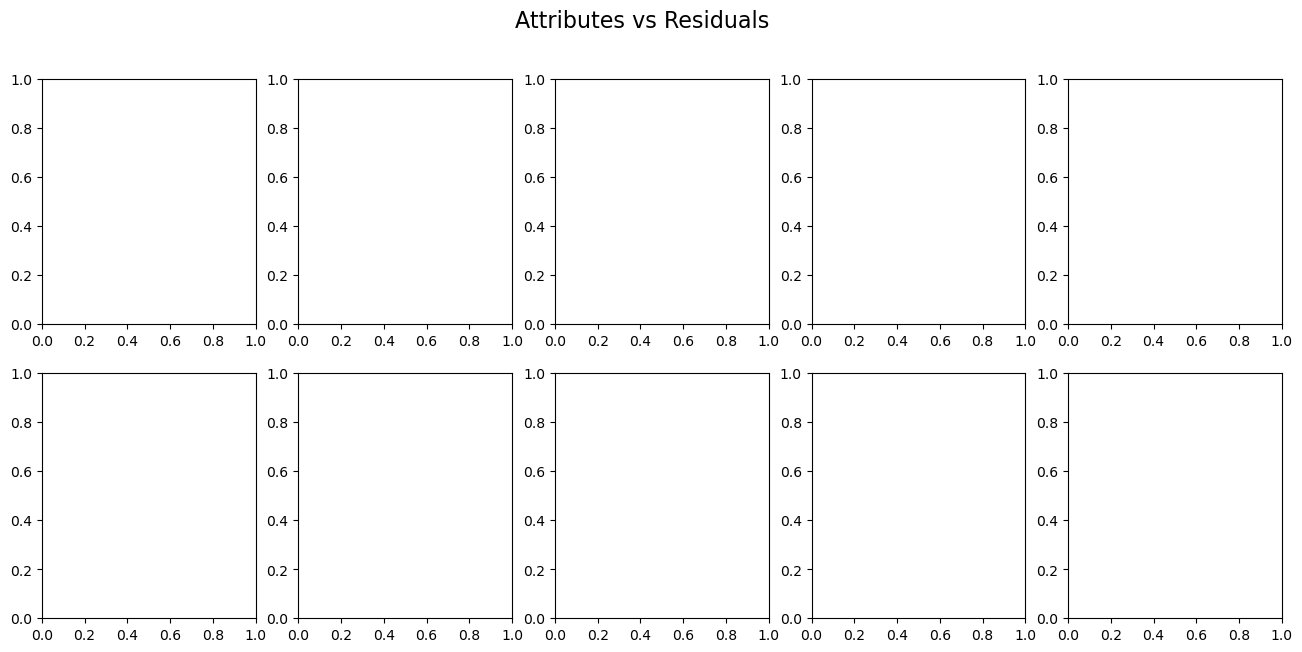

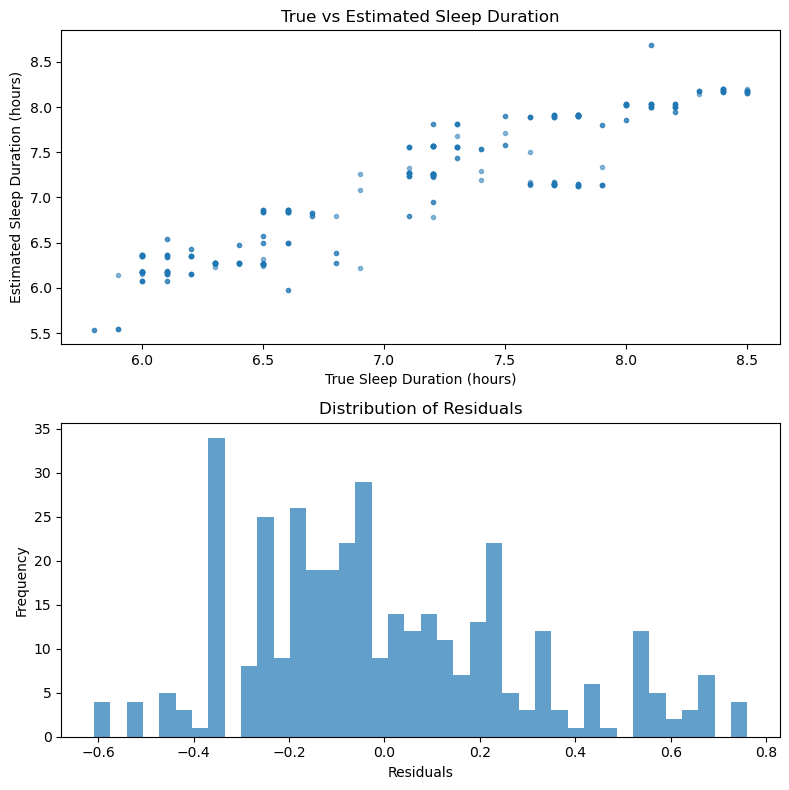

Estimated model parameters:
Age: 0.014
Quality of Sleep: 0.253
Physical Activity Level: 0.007
Stress Level: -0.235
Heart Rate: 0.036
Daily Steps: -0.000
Gender_Male: 0.137
BMI Category_Obese: -0.805
BMI Category_Overweight: -0.531
Blood Pressure_Prehigh: 0.438
Blood Pressure_Stage 1 high: 0.412

Intercept: 3.183

Mean Squared Error (MSE): 0.084


In [23]:
# Drop identifiers and target columns
X = dat.drop(
    columns=["Sleep Duration", "Sleep Disorder", "Person ID", "Occupation"],
    errors="ignore"
)
y = dat["Sleep Duration"]

# Convert categorical variables into dummy/indicator variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Fit the linear regression model
model = lm.LinearRegression(fit_intercept=True)
model.fit(X_encoded, y)

# Estimated parameters (intercept and coefficients)
w_star = np.hstack([model.intercept_, model.coef_.flatten()])

# Predict sleep duration
y_est = model.predict(X_encoded)

# Calculate residuals
residual = y - y_est

# Display scatter plot and histogram of residuals
fig, axs = plt.subplots(2, 1, figsize=(8, 8))

axs[0].scatter(y, y_est, marker='.', alpha=0.5)
axs[0].set_xlabel("True Sleep Duration (hours)")
axs[0].set_ylabel("Estimated Sleep Duration (hours)")
axs[0].set_title("True vs Estimated Sleep Duration")

axs[1].hist(residual, bins=40, alpha=0.7)
axs[1].set_xlabel("Residuals")
axs[1].set_ylabel("Frequency")
axs[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

# Print estimated parameters
print("\033[1mEstimated model parameters:\033[0;0m")

for i, name in enumerate(X_encoded.columns):
    print(f"{name}: {w_star[i+1]:.3f}")

print(f"\nIntercept: {w_star[0]:.3f}")
print(f"\nMean Squared Error (MSE): {np.mean(residual**2):.3f}")

### 6.2 Feature and Residual Diagnostics

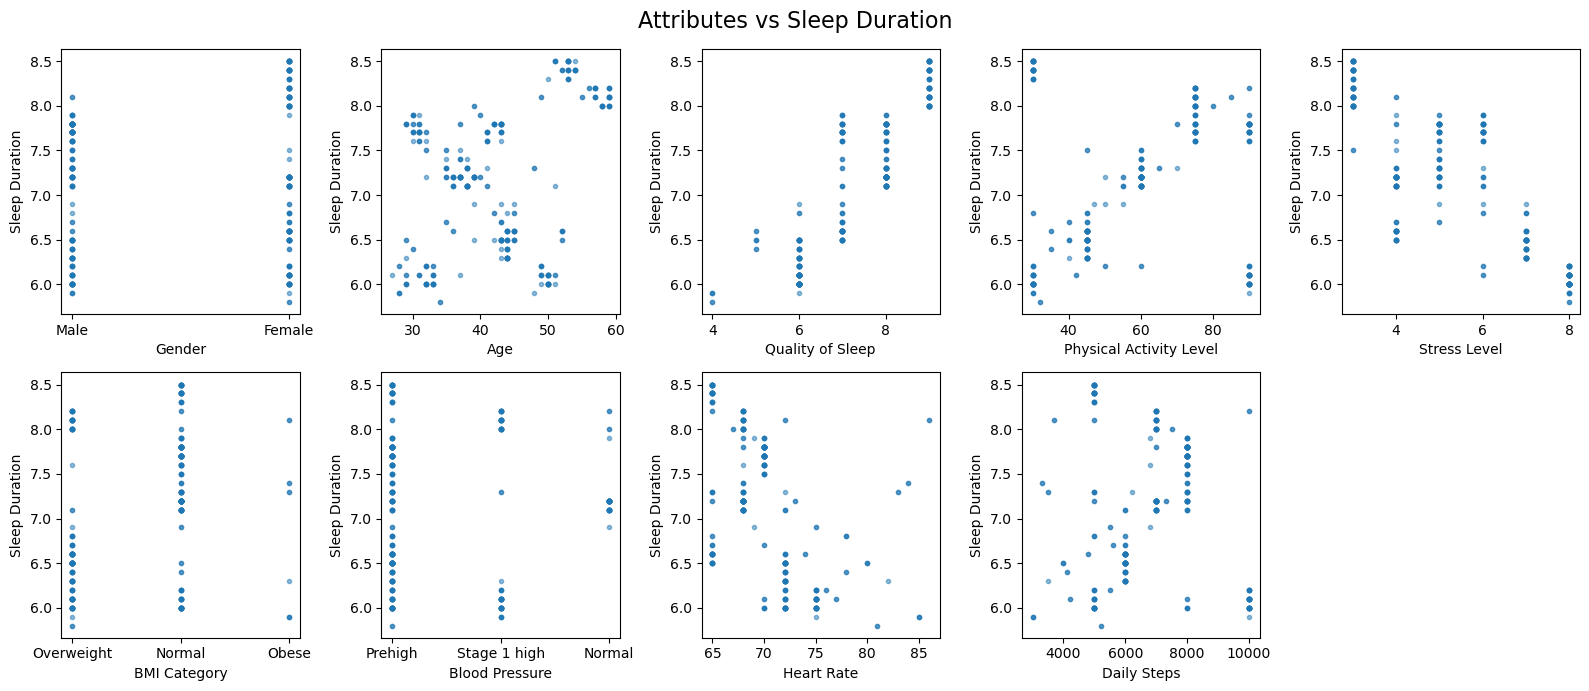

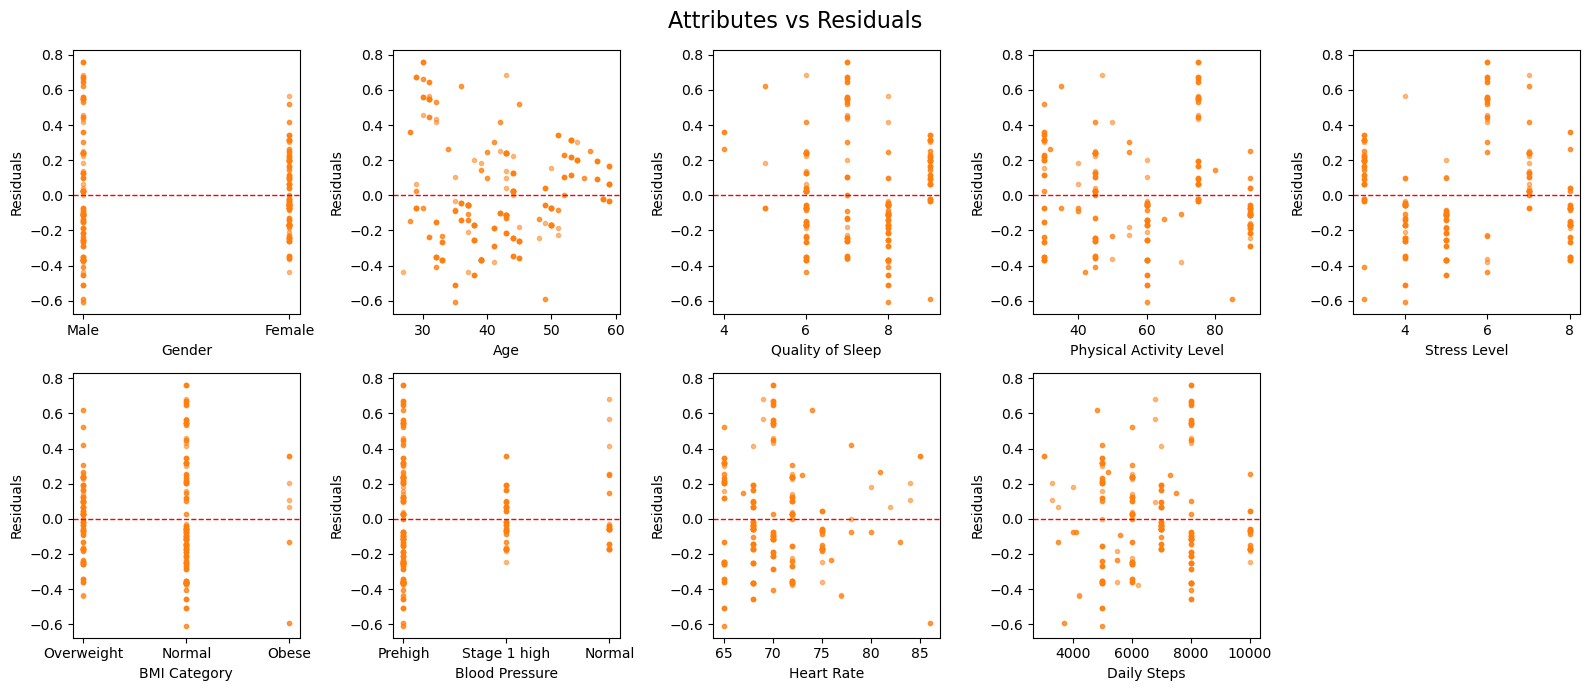

In [24]:
# Feature and residual diagnostics
n = len(X.columns)
ncols = math.ceil(n / 2)   
fig, axs = plt.subplots(2, ncols, figsize=(16, 7))
fig.suptitle("Attributes vs Sleep Duration", fontsize=16)

axs = axs.ravel()  
for i, attribute in enumerate(X.columns):
    axs[i].scatter(X[attribute], y, marker='.', alpha=0.5)
    axs[i].set_xlabel(attribute)
    axs[i].set_ylabel("Sleep Duration")

for j in range(i+1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

# --- Attributes vs Residuals ---
fig, axs = plt.subplots(2, ncols, figsize=(16, 7))
fig.suptitle("Attributes vs Residuals", fontsize=16)
axs = axs.ravel()

residual = y - y_est  # compute once

for i, attribute in enumerate(X.columns):
    axs[i].scatter(X[attribute], residual, marker='.', alpha=0.5, color='C1')
    axs[i].axhline(0, color='red', ls='--', lw=1)
    axs[i].set_xlabel(attribute)
    axs[i].set_ylabel("Residuals")

for j in range(i+1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()


### 6.3 Nonlinear Feature Transformations

MSE: 0.08202603136528618


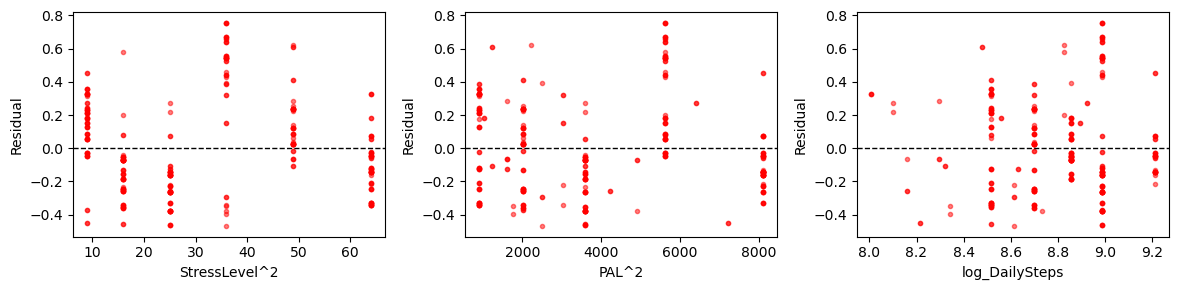

In [25]:
# Nonlinear feature transformations
Xt = X_encoded.copy()

if "Stress Level" in Xt.columns:
    Xt["StressLevel^2"] = (dat["Stress Level"]**2).to_numpy()
if "Physical Activity Level" in Xt.columns:
    Xt["PAL^2"] = (dat["Physical Activity Level"]**2).to_numpy()
if "Daily Steps" in Xt.columns:
    Xt["log_DailySteps"] = np.log1p(dat["Daily Steps"]).to_numpy()  # log(1+x) for stability

# Fit ordinary least squares regression model
model_t = lm.LinearRegression()
model_t.fit(Xt, y)
y_est_t = model_t.predict(Xt)
residual_t = y - y_est_t
print("MSE:", np.mean(residual_t**2))

# Plot transformed features vs residuals (subset)
show_cols = [c for c in Xt.columns if c.endswith("^2") or c.startswith("log_")]
nshow = min(len(show_cols), 4)
if nshow > 0:
    fig, axs = plt.subplots(1, nshow, figsize=(12, 3))
    for i, attr in enumerate(show_cols[:nshow]):
        axs[i].scatter(Xt[attr], residual_t, marker='.', color='r', alpha=0.5)
        axs[i].axhline(0, color='k', ls='--', lw=1)
        axs[i].set_xlabel(attr)
        axs[i].set_ylabel("Residual")
    plt.tight_layout(); plt.show()


### 6.4 Ridge Regression with 10-Fold Cross-Validation

Best λ: 4.924 | 10-fold CV MSE: 0.0900


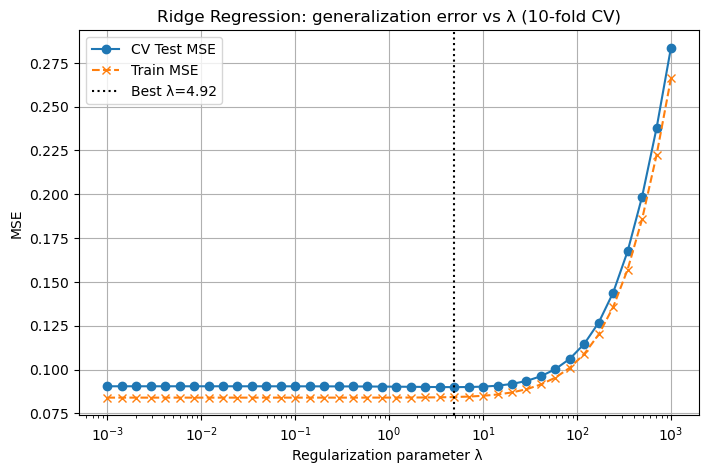


Top coefficients (inputs standardized):
Stress Level                  -0.369894
Quality of Sleep               0.325433
BMI Category_Overweight       -0.241851
Blood Pressure_Prehigh         0.187358
Physical Activity Level        0.158629
Blood Pressure_Stage 1 high    0.140565
Heart Rate                     0.118145
Age                            0.112167
BMI Category_Obese            -0.105665
Daily Steps                   -0.093836
Gender_Male                    0.061590
dtype: float64

Final train MSE (best λ): 0.08432272115178052


In [26]:
# PART a
Z = X_encoded.copy()  

# 1) Standardize columns to mean 0, std 1 (as the brief requires)
scaler = StandardScaler(with_mean=True, with_std=True)
Z_std = scaler.fit_transform(Z)

# 2) Ridge regularization: 10-fold CV across a λ (alpha) grid
lambdas = np.logspace(-3, 3, 40)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_mse = []
train_mse = []
for a in lambdas:
    ridge = Ridge(alpha=a, random_state=0)
    # CV test error (negative MSE -> MSE)
    mse_scores = -cross_val_score(ridge, Z_std, y, cv=kf, scoring="neg_mean_squared_error")
    cv_mse.append(mse_scores.mean())
    # train error for curve shape
    ridge.fit(Z_std, y)
    train_mse.append(mean_squared_error(y, ridge.predict(Z_std)))

best_idx = int(np.argmin(cv_mse))
best_lambda = lambdas[best_idx]
print(f"Best λ: {best_lambda:.4g} | 10-fold CV MSE: {cv_mse[best_idx]:.4f}")

# 2b) Plot generalization error vs λ
plt.figure(figsize=(8,5))
plt.semilogx(lambdas, cv_mse, "o-", label="CV Test MSE")
plt.semilogx(lambdas, train_mse, "x--", label="Train MSE")
plt.axvline(best_lambda, color="k", ls=":", label=f"Best λ={best_lambda:.3g}")
plt.xlabel("Regularization parameter λ ")
plt.ylabel("MSE")
plt.title("Ridge Regression: generalization error vs λ (10-fold CV)")
plt.legend(); plt.grid(True); plt.show()

# 3) Fit best model on full data and interpret coefficients
best_ridge = Ridge(alpha=best_lambda, random_state=0).fit(Z_std, y)
coefs = pd.Series(best_ridge.coef_, index=Z.columns).sort_values(key=np.abs, ascending=False)

print("\nTop coefficients (inputs standardized):")
print(coefs.head(12))

y_hat = best_ridge.predict(Z_std)
print("\nFinal train MSE (best λ):", mean_squared_error(y, y_hat))


## 7. Classification — Predicting Sleep Disorder

### 7.1 Classification Implementation 1

c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Foun

,Outer fold,KNN (param*),KNN E_test,LogReg (C*),LogReg E_test,Baseline E_test
0,1,k*=5,0.052632,3.73,0.052632,0.421053
1,2,k*=5,0.157895,1e+04,0.052632,0.421053
2,3,k*=5,0.078947,3.73,0.078947,0.421053
3,4,k*=15,0.052632,3.73,0.026316,0.421053
4,5,k*=11,0.189189,1,0.162162,0.405405
5,6,k*=5,0.162162,193,0.108108,0.405405
6,7,k*=7,0.162162,193,0.189189,0.405405
7,8,k*=7,0.162162,720,0.189189,0.405405
8,9,k*=7,0.162162,193,0.135135,0.405405
9,10,k*=11,0.081081,0.268,0.054054,0.432432



Mean error rates across outer folds:
KNN: 0.1261
Logistic Regression: 0.1048
Baseline: 0.4144


c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Foun

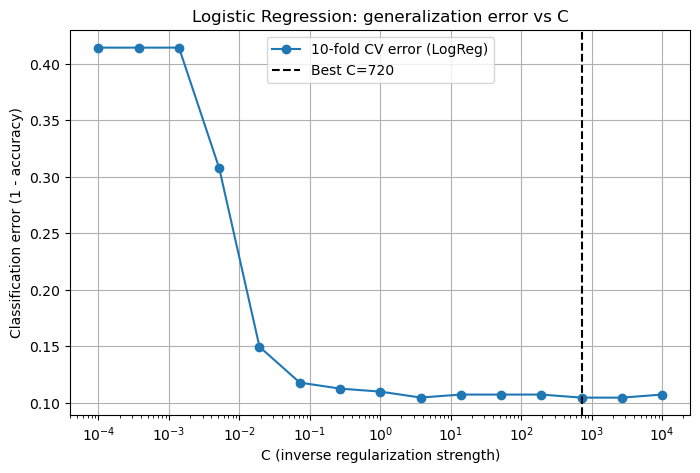

In [27]:
K1 = 10   # outer folds
K2 = 10   # inner folds
random_state = 42
use_method2 = "knn" 

# Hyperparameter grids
C_values = np.logspace(-4, 4, 15)      
k_values = [1, 3, 5, 7, 9, 11, 15, 21] 

df = dat.copy()

# Clean up Sleep Disorder labels 
if "Sleep Disorder" in df.columns:
    df["Sleep Disorder"] = (
        df["Sleep Disorder"]
        .replace({"NONE": "No Disorder", "None": "No Disorder"})
        .fillna("No Disorder")
    )

y = df["Sleep Disorder"]
X = df.drop(columns=["Person ID", "Sleep Duration", "Sleep Disorder"], errors="ignore")

if "Blood Pressure" in X.columns and isinstance(X["Blood Pressure"].iloc[0], str) and "/" in X["Blood Pressure"].iloc[0]:
    bp = X["Blood Pressure"].str.split("/", expand=True).rename(columns={0:"BP_Systolic",1:"BP_Diastolic"}).astype(float)
    X = pd.concat([X.drop(columns=["Blood Pressure"]), bp], axis=1)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop",
)

# Build pipelines
logreg_pipe = Pipeline(steps=[
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=1000, multi_class="multinomial", solver="lbfgs"))
])

if use_method2 == "knn":
    method2_name = "KNN"
    method2_pipe = Pipeline(steps=[
        ("pre", pre),
        ("clf", KNeighborsClassifier())
    ])
else:

    from sklearn.naive_bayes import MultinomialNB
    method2_name = "Naive Bayes"
    method2_pipe = Pipeline(steps=[
        ("pre", pre),
        ("clf", MultinomialNB(alpha=1.0))
    ])

# TWO-LEVEL CROSS-VALIDATION 
outer_cv = StratifiedKFold(n_splits=K1, shuffle=True, random_state=random_state)
inner_cv = StratifiedKFold(n_splits=K2, shuffle=True, random_state=random_state)

rows = []
outer_idx = 0

for train_idx, test_idx in outer_cv.split(X, y):
    outer_idx += 1
    X_par, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_par, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # ---------------- Logistic Regression: inner CV over C ----------------
    best_C = None
    best_log_cv_err = np.inf

    for C in C_values:
        candidate = clone(logreg_pipe).set_params(clf__C=C)
        # CV accuracy on parameter-tuning folds (lower error is better)
        scores = cross_val_score(candidate, X_par, y_par, cv=inner_cv, scoring="accuracy")
        mean_err = 1 - scores.mean()
        if mean_err < best_log_cv_err:
            best_log_cv_err = mean_err
            best_C = C

    # Fit best logistic on D_par_i and evaluate on D_test_i
    best_log_model = clone(logreg_pipe).set_params(clf__C=best_C)
    best_log_model.fit(X_par, y_par)
    y_pred_log = best_log_model.predict(X_test)
    log_test_err = 1 - accuracy_score(y_test, y_pred_log)

    # ---------------- Method 2 (KNN or NB): inner CV over k (or alpha) ----------------
    if method2_name == "KNN":
        best_k = None
        best_m2_cv_err = np.inf
        for k in k_values:
            candidate = clone(method2_pipe).set_params(clf__n_neighbors=k)
            scores = cross_val_score(candidate, X_par, y_par, cv=inner_cv, scoring="accuracy")
            mean_err = 1 - scores.mean()
            if mean_err < best_m2_cv_err:
                best_m2_cv_err = mean_err
                best_k = k
        # Fit best method2 and evaluate
        best_m2_model = clone(method2_pipe).set_params(clf__n_neighbors=best_k)
        best_m2_model.fit(X_par, y_par)
        y_pred_m2 = best_m2_model.predict(X_test)
        m2_test_err = 1 - accuracy_score(y_test, y_pred_m2)
        method2_param_display = f"k*={best_k}"
    else:
        # Naive Bayes alpha tuning example (if you choose NB)
        alphas = np.logspace(-3, 1, 9)  # 0.001..10
        best_alpha = None
        best_m2_cv_err = np.inf
        for a in alphas:
            candidate = clone(method2_pipe).set_params(clf__alpha=a)
            scores = cross_val_score(candidate, X_par, y_par, cv=inner_cv, scoring="accuracy")
            mean_err = 1 - scores.mean()
            if mean_err < best_m2_cv_err:
                best_m2_cv_err = mean_err
                best_alpha = a
        best_m2_model = clone(method2_pipe).set_params(clf__alpha=best_alpha)
        best_m2_model.fit(X_par, y_par)
        y_pred_m2 = best_m2_model.predict(X_test)
        m2_test_err = 1 - accuracy_score(y_test, y_pred_m2)
        method2_param_display = f"alpha*={best_alpha:.3g}"

    # ---------------- Baseline on D_test_i ----------------
    # Predict the majority class from D_par_i for all X_test
    majority_class = y_par.value_counts().idxmax()
    y_pred_base = np.full_like(y_test, fill_value=majority_class)
    base_test_err = 1 - accuracy_score(y_test, y_pred_base)

    # ---------------- Store row for the table ----------------
    rows.append({
        "Outer fold": outer_idx,
        f"{method2_name} (param*)": method2_param_display,
        f"{method2_name} E_test": m2_test_err,
        "LogReg (C*)": f"{best_C:.3g}",
        "LogReg E_test": log_test_err,
        "Baseline E_test": base_test_err
    })

# Results table 
table_cls = pd.DataFrame(rows)
display(table_cls)

print("\nMean error rates across outer folds:")
print(f"{method2_name}: {table_cls[f'{method2_name} E_test'].mean():.4f}")
print(f"Logistic Regression: {table_cls['LogReg E_test'].mean():.4f}")
print(f"Baseline: {table_cls['Baseline E_test'].mean():.4f}")

# Error vs Regularization plot (LogReg) on the whole dataset (CV estimate)
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
cv_errors = []

for C in C_values:
    m = clone(logreg_pipe).set_params(clf__C=C)
    scores = cross_val_score(m, X, y, cv=cv, scoring="accuracy")
    cv_errors.append(1 - scores.mean())

best_idx = int(np.argmin(cv_errors))
best_C_global = C_values[best_idx]

plt.figure(figsize=(8,5))
plt.semilogx(C_values, cv_errors, "o-", label="10-fold CV error (LogReg)")
plt.axvline(best_C_global, color="k", ls="--", label=f"Best C={best_C_global:.3g}")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Classification error (1 - accuracy)")
plt.title("Logistic Regression: generalization error vs C")
plt.legend(); plt.grid(True); plt.show()


### 7.2 Classification Implementation 2

Numeric features: ['Age', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']
Categorical features: ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure']


c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Foun

,Outer fold,LogReg (C*),LogReg E_test,KNN (k*),KNN E_test,Baseline E_test
0,1,3.73,0.052632,11,0.026316,0.421053
1,2,2.68e+03,0.052632,7,0.131579,0.421053
2,3,13.9,0.078947,11,0.078947,0.421053
3,4,13.9,0.052632,9,0.078947,0.421053
4,5,1,0.162162,11,0.189189,0.405405
5,6,3.73,0.108108,7,0.135135,0.405405
6,7,0.268,0.189189,5,0.189189,0.405405
7,8,13.9,0.162162,7,0.216216,0.405405
8,9,51.8,0.135135,5,0.162162,0.405405
9,10,1,0.054054,7,0.081081,0.432432



Mean error rates across outer folds:
Logistic Regression: 0.1048
KNN:                 0.1289
Baseline:            0.4144


c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Foun

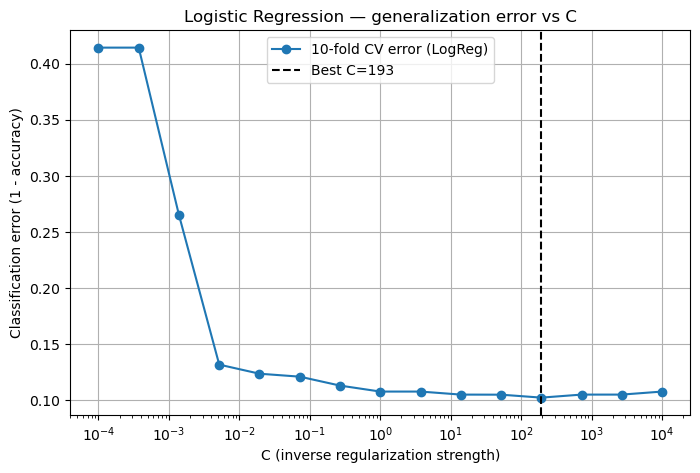

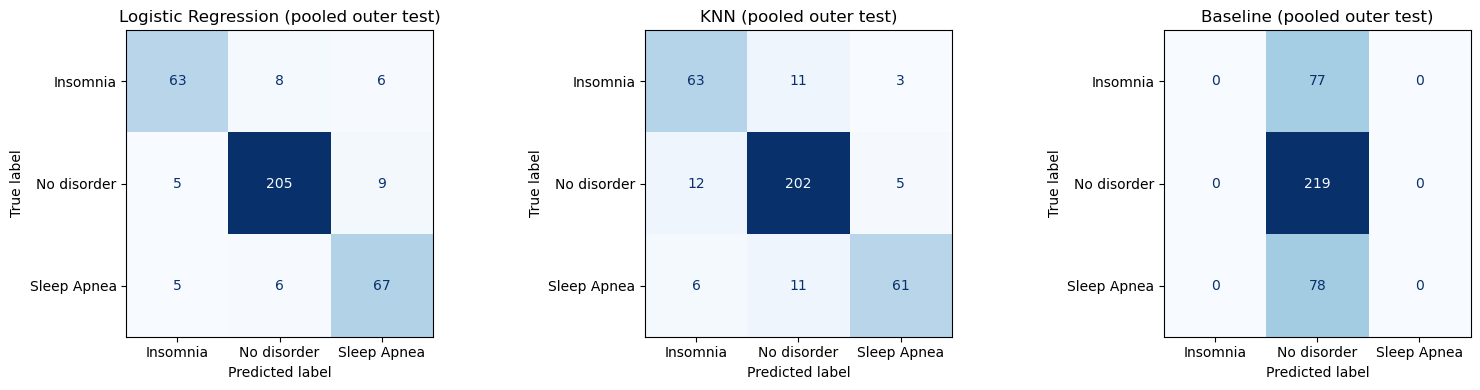

In [ ]:
df = dat.copy()

if "Sleep Disorder" in df.columns:
    df["Sleep Disorder"] = (
        df["Sleep Disorder"]
        .replace({"NONE": "No Disorder", "None": "No Disorder"})
        .fillna("No Disorder")
    )

# Parse "Blood Pressure" like "120/80" -> numeric columns 
if "Blood Pressure" in df.columns and isinstance(df["Blood Pressure"].iloc[0], str) and "/" in df["Blood Pressure"].iloc[0]:
    bp = df["Blood Pressure"].str.split("/", expand=True).rename(columns={0:"BP_Systolic", 1:"BP_Diastolic"})
    # convert safely to float
    for c in bp.columns:
        bp[c] = pd.to_numeric(bp[c], errors="coerce")
    df = pd.concat([df.drop(columns=["Blood Pressure"]), bp.astype(float)], axis=1)

# Features and target
y = df["Sleep Disorder"]
X = df.drop(columns=["Person ID", "Sleep Duration", "Sleep Disorder"], errors="ignore")

# Identify numeric vs categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)


# Preprocessing
try:
    ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)

pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols),
    ],
    remainder="drop",
)

# Pipelines
logreg_pipe = Pipeline(steps=[
    ("pre", pre),
    ("scale_all", StandardScaler(with_mean=True, with_std=True)),  # ensure every column is standardized
    ("clf", LogisticRegression(max_iter=1000, multi_class="multinomial", solver="lbfgs"))
])

knn_pipe = Pipeline(steps=[
    ("pre", pre),
    ("scale_all", StandardScaler(with_mean=True, with_std=True)),
    ("clf", KNeighborsClassifier())
])

# Two-level CV
K1 = 10  # outer
K2 = 10  # inner
rng = 42

outer_cv = StratifiedKFold(n_splits=K1, shuffle=True, random_state=rng)
inner_cv = StratifiedKFold(n_splits=K2, shuffle=True, random_state=rng)

C_values = np.logspace(-4, 4, 15)           # logistic reg (C = 1/lambda)
k_values = [1, 3, 5, 7, 9, 11, 15, 21]      # KNN k grid

rows = []
outer_fold = 0

# Store pooled predictions for a confusion matrix across all outer test folds
all_true, all_pred_log, all_pred_knn, all_pred_base = [], [], [], []

for tr_idx, te_idx in outer_cv.split(X, y):
    outer_fold += 1
    X_par, X_test = X.iloc[tr_idx], X.iloc[te_idx]
    y_par, y_test = y.iloc[tr_idx], y.iloc[te_idx]

    # --- Logistic Regression: inner CV over C ---
    best_C, best_log_cv_err = None, np.inf
    for C in C_values:
        m = clone(logreg_pipe).set_params(clf__C=C)
        acc = cross_val_score(m, X_par, y_par, cv=inner_cv, scoring="accuracy").mean()
        err = 1 - acc
        if err < best_log_cv_err:
            best_log_cv_err, best_C = err, C

    best_log_model = clone(logreg_pipe).set_params(clf__C=best_C).fit(X_par, y_par)
    y_pred_log = best_log_model.predict(X_test)
    log_test_err = 1 - accuracy_score(y_test, y_pred_log)

    # --- KNN: inner CV over k ---
    best_k, best_knn_cv_err = None, np.inf
    for k in k_values:
        m = clone(knn_pipe).set_params(clf__n_neighbors=k)
        acc = cross_val_score(m, X_par, y_par, cv=inner_cv, scoring="accuracy").mean()
        err = 1 - acc
        if err < best_knn_cv_err:
            best_knn_cv_err, best_k = err, k

    best_knn_model = clone(knn_pipe).set_params(clf__n_neighbors=best_k).fit(X_par, y_par)
    y_pred_knn = best_knn_model.predict(X_test)
    knn_test_err = 1 - accuracy_score(y_test, y_pred_knn)

    # --- Baseline: majority class from parent split ---
    majority = y_par.value_counts().idxmax()
    y_pred_base = pd.Series([majority] * len(y_test), index=y_test.index)
    base_test_err = 1 - accuracy_score(y_test, y_pred_base)

    rows.append({
        "Outer fold": outer_fold,
        "LogReg (C*)": f"{best_C:.3g}",
        "LogReg E_test": log_test_err,
        "KNN (k*)": best_k,
        "KNN E_test": knn_test_err,
        "Baseline E_test": base_test_err
    })

    # Collect for pooled confusion matrices / tests
    all_true.append(y_test.to_numpy())
    all_pred_log.append(y_pred_log)
    all_pred_knn.append(y_pred_knn)
    all_pred_base.append(y_pred_base.to_numpy())

table_cls = pd.DataFrame(rows)
display(table_cls)

print("\nMean error rates across outer folds:")
print(f"Logistic Regression: {table_cls['LogReg E_test'].mean():.4f}")
print(f"KNN:                 {table_cls['KNN E_test'].mean():.4f}")
print(f"Baseline:            {table_cls['Baseline E_test'].mean():.4f}")

# Error vs Regularization curve 
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=rng)
cv_errors = []
for C in C_values:
    m = clone(logreg_pipe).set_params(clf__C=C)
    acc = cross_val_score(m, X, y, cv=cv, scoring="accuracy").mean()
    cv_errors.append(1 - acc)

best_idx = int(np.argmin(cv_errors))
best_C_global = C_values[best_idx]

plt.figure(figsize=(8,5))
plt.semilogx(C_values, cv_errors, "o-", label="10-fold CV error (LogReg)")
plt.axvline(best_C_global, color="k", ls="--", label=f"Best C={best_C_global:.3g}")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Classification error (1 - accuracy)")
plt.title("Logistic Regression — generalization error vs C")
plt.legend(); plt.grid(True); plt.show()

# Pooled confusion matrices 
y_true = np.concatenate(all_true)
yhat_log = np.concatenate(all_pred_log)
yhat_knn = np.concatenate(all_pred_knn)
yhat_base = np.concatenate(all_pred_base)

labels = np.unique(y_true)

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for ax, yhat, title in zip(
    axs,
    [yhat_log, yhat_knn, yhat_base],
    ["Logistic Regression (pooled outer test)", "KNN (pooled outer test)", "Baseline (pooled outer test)"]
):
    cm = confusion_matrix(y_true, yhat, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()


### 7.3 Classification with Pairwise McNemar Tests

Numeric features: ['Age', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']
Categorical features: ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure']


c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\harja\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Foun

Errors per outer fold (KNN | Baseline | LOGREG):
 0.120		 0.413		 0.133
 0.093		 0.413		 0.067
 0.107		 0.413		 0.107
 0.147		 0.413		 0.107
 0.149		 0.419		 0.108

Mean error rates across outer folds:
KNN:                 0.1231
Baseline:            0.4145
Logistic Regression: 0.1043


<Figure size 640x480 with 0 Axes>

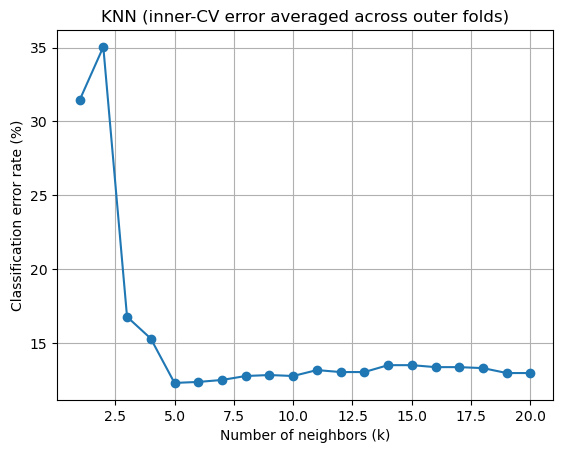

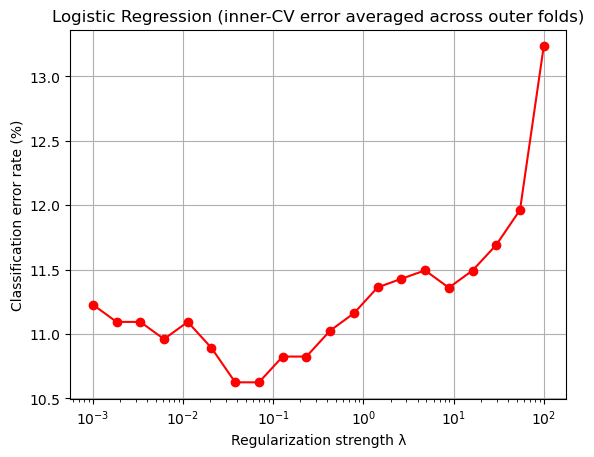

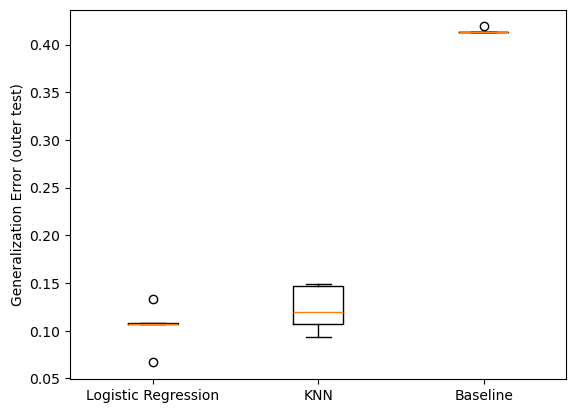


A : Baseline  | B : KNN
theta: 0.773  CI: [0.608 0.938]  p: 0.0

A : Baseline  | B : Logistic Regression
theta: 0.806  CI: [0.642 0.969]  p: 0.0

A : KNN       | B : Logistic Regression
theta: 0.467  CI: [-0.039  0.973]  p: 0.2369


In [30]:
def mcnemar(y_true, yhatA, yhatB, alpha=0.05):
    """
    Perform McNemar's test for two classifiers A and B.
    Returns: theta (error difference), confidence interval, and p-value.
    """
    # Boolean arrays of correct classifications
    a_correct = (yhatA == y_true)
    b_correct = (yhatB == y_true)

    # Contingency counts
    n01 = np.sum(~a_correct & b_correct)   # A wrong, B correct
    n10 = np.sum(a_correct & ~b_correct)   # A correct, B wrong
    n = n01 + n10

    if n == 0:
        print("No disagreements between classifiers — McNemar not defined.")
        return 0, (0, 0), 1.0

    # Exact binomial test (two-sided)
    p = 2 * binomtest(k=min(n01, n10), n=n, p=0.5, alternative='two-sided').pvalue

    # estimated difference in proportions (theta)
    theta_hat = (n01 - n10) / n

    # approximate 95% confidence interval
    se = np.sqrt((n01 + n10) / n**2)
    z = 1.96
    CI = (theta_hat - z * se, theta_hat + z * se)

    return theta_hat, CI, p


df = dat.copy()

if "Sleep Disorder" in df.columns:
    df["Sleep Disorder"] = (
        df["Sleep Disorder"]
        .replace({"NONE": "No Disorder", "None": "No Disorder"})
        .fillna("No Disorder")
    )

if "Blood Pressure" in df.columns and isinstance(df["Blood Pressure"].iloc[0], str) and "/" in df["Blood Pressure"].iloc[0]:
    bp = df["Blood Pressure"].str.split("/", expand=True).rename(columns={0:"BP_Systolic", 1:"BP_Diastolic"})
    for c in bp.columns:
        bp[c] = pd.to_numeric(bp[c], errors="coerce")
    df = pd.concat([df.drop(columns=["Blood Pressure"]), bp.astype(float)], axis=1)


y_text = df["Sleep Disorder"]
X = df.drop(columns=["Person ID", "Sleep Duration", "Sleep Disorder"], errors="ignore")

le = LabelEncoder()
y = le.fit_transform(y_text)
class_names = le.classes_

# Identify numeric vs categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)


try:
    ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
except TypeError:
    # for older sklearn
    ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)

pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols),
    ],
    remainder="drop",
)

logreg_pipe = Pipeline(steps=[
    ("pre", pre),
    ("scale_all", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(max_iter=1000, multi_class="multinomial", solver="lbfgs"))
])

knn_pipe = Pipeline(steps=[
    ("pre", pre),
    ("scale_all", StandardScaler(with_mean=True, with_std=True)),
    ("clf", KNeighborsClassifier())
])

K1 = 5
K2 = 5
rng = 1

outer_cv = StratifiedKFold(n_splits=K1, shuffle=True, random_state=rng)
inner_cv = StratifiedKFold(n_splits=K2, shuffle=True, random_state=rng)

lambda_interval = np.logspace(-3, 2, 20)   # for Logistic (λ); sklearn uses C = 1/λ
k_grid = np.arange(1, 21)                   # for KNN (1..20)

# Storage for outer results
error1_logreg = np.zeros(K1)    # outer test error per fold (logreg)
error1_knn    = np.zeros(K1)    # outer test error per fold (knn)
error_baseline = np.zeros(K1)   # outer test error per fold (baseline)

opt_lambda = np.zeros(K1)       # chosen λ per outer fold (logreg)
opt_k = np.zeros(K1, dtype=int) # chosen k per outer fold (knn)

inner_errs_logreg = []  # each element: mean inner error array over lambdas for this outer fold
inner_errs_knn = []     # each element: mean inner error array over k for this outer fold

y_true_all = []
yhat_base_all = []
yhat_knn_all = []
yhat_logreg_all = []

for n, (train_idx1, test_idx1) in enumerate(outer_cv.split(X, y)):
    X_parent, X_test = X.iloc[train_idx1], X.iloc[test_idx1]
    y_parent, y_test = y[train_idx1], y[test_idx1]

    # ----- Inner CV: Logistic over λ (via C=1/λ) -----
    inner_errors_for_lambdas = []
    for lam in lambda_interval:
        C = 1.0 / lam
        candidate = clone(logreg_pipe).set_params(clf__C=C)
        acc = cross_val_score(candidate, X_parent, y_parent, cv=inner_cv, scoring="accuracy").mean()
        inner_errors_for_lambdas.append(1 - acc)
    inner_errors_for_lambdas = np.array(inner_errors_for_lambdas)
    inner_errs_logreg.append(inner_errors_for_lambdas)

    best_idx = int(np.argmin(inner_errors_for_lambdas))
    best_lambda = lambda_interval[best_idx]
    opt_lambda[n] = best_lambda

    best_log_model = clone(logreg_pipe).set_params(clf__C=1.0/best_lambda)
    best_log_model.fit(X_parent, y_parent)
    y_pred_log = best_log_model.predict(X_test)
    error1_logreg[n] = 1 - accuracy_score(y_test, y_pred_log)

    # ----- Inner CV: KNN over k -----
    inner_errors_for_k = []
    for k in k_grid:
        candidate = clone(knn_pipe).set_params(clf__n_neighbors=k)
        acc = cross_val_score(candidate, X_parent, y_parent, cv=inner_cv, scoring="accuracy").mean()
        inner_errors_for_k.append(1 - acc)
    inner_errors_for_k = np.array(inner_errors_for_k)
    inner_errs_knn.append(inner_errors_for_k)

    best_k_idx = int(np.argmin(inner_errors_for_k))
    best_k = int(k_grid[best_k_idx])
    opt_k[n] = best_k

    best_knn_model = clone(knn_pipe).set_params(clf__n_neighbors=best_k)
    best_knn_model.fit(X_parent, y_parent)
    y_pred_knn = best_knn_model.predict(X_test)
    error1_knn[n] = 1 - accuracy_score(y_test, y_pred_knn)

    # ----- Baseline (majority class from parent set) -----
    baseline = np.argmax(np.bincount(y_parent))
    y_pred_base = np.full_like(y_test, baseline)
    error_baseline[n] = 1 - accuracy_score(y_test, y_pred_base)

    # ----- Collect for McNemar -----
    y_true_all.append(y_test)
    yhat_base_all.append(y_pred_base)
    yhat_knn_all.append(y_pred_knn)
    yhat_logreg_all.append(y_pred_log)

# Concatenate pooled predictions (outer test folds)
y_true = np.concatenate(y_true_all)
yhat_base = np.concatenate(yhat_base_all)
yhat_knn = np.concatenate(yhat_knn_all)
yhat_logreg = np.concatenate(yhat_logreg_all)

# Report per-fold errors
print('Errors per outer fold (KNN | Baseline | LOGREG):')
for m in range(K1):
    print(f' {error1_knn[m]:.3f}\t\t {error_baseline[m]:.3f}\t\t {error1_logreg[m]:.3f}')

print("\nMean error rates across outer folds:")
print(f"KNN:                 {error1_knn.mean():.4f}")
print(f"Baseline:            {error_baseline.mean():.4f}")
print(f"Logistic Regression: {error1_logreg.mean():.4f}")

# Inner CV curves (averaged across outer folds) for plotting
mean_inner_logreg = np.vstack(inner_errs_logreg).mean(axis=0) * 100.0  
mean_inner_knn    = np.vstack(inner_errs_knn).mean(axis=0) * 100.0     

plt.figure()
plt.plot(k_grid, mean_inner_knn, '-o')
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Classification error rate (%)')
plt.title('KNN (inner-CV error averaged across outer folds)')
plt.grid(True)
plt.savefig('KNN.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
plt.semilogx(lambda_interval, mean_inner_logreg, '-or')
plt.xlabel('Regularization strength λ')
plt.ylabel('Classification error rate (%)')
plt.title('Logistic Regression (inner-CV error averaged across outer folds)')
plt.grid(True)
plt.savefig('Logistic_Regression.png', dpi=300, bbox_inches='tight')
plt.show()

# Boxplot of outer test errors
fig = plt.figure()
boxes_df = pd.DataFrame({
    'Logistic Regression': error1_logreg,
    'KNN': error1_knn,
    'Baseline': error_baseline
})

plt.boxplot(boxes_df.values)
plt.ylabel('Generalization Error (outer test)')
plt.xticks([1, 2, 3], boxes_df.columns)
plt.savefig('boxplot_classification.png', dpi=300, bbox_inches='tight')
plt.show()

# McNemar tests 
alpha = 0.05

print('\nA : Baseline  | B : KNN')
thetahat, CI, p = mcnemar(y_true, yhat_base, yhat_knn, alpha=alpha)
print('theta:', np.round(thetahat, 3), ' CI:', np.round(CI, 3), ' p:', np.round(p, 4))

print('\nA : Baseline  | B : Logistic Regression')
thetahat, CI, p = mcnemar(y_true, yhat_base, yhat_logreg, alpha=alpha)
print('theta:', np.round(thetahat, 3), ' CI:', np.round(CI, 3), ' p:', np.round(p, 4))

print('\nA : KNN       | B : Logistic Regression')
thetahat, CI, p = mcnemar(y_true, yhat_knn, yhat_logreg, alpha=alpha)
print('theta:', np.round(thetahat, 3), ' CI:', np.round(CI, 3), ' p:', np.round(p, 4))
